# improve_data_label_v23 (based on v22)

v20: v19(로더/체크포인트 안정화) + **좌표 초기화/출력 경로 수정**으로 예측 붕괴(선분/클러스터) 문제를 해결한 버전.

- 핵심 수정: EGNN 내부 좌표 `x`를 0으로 시작하지 않고, **학습 가능한 init_x(h)** 로 초기화 → 좌표 업데이트가 실제로 동작
- 출력: `preds = x + head_offset(h)` 구조로 v12 스타일 복원 (멀티헤드 유지)


## v15 변경점 (v14 대비 예측 붕괴/좌표 업데이트 무력화 해결)

1) **좌표 초기화(degenerate zero-init) 제거**
- v13/v14는 `x=0`에서 시작해 `dx = (xi-xj)*w` 이라서 **항상 dx=0 → x가 영원히 0** 문제가 생길 수 있음
- v15는 `x = init_x(h)` 로 시작해 **rij가 0이 아니게 만들고**, EGNN의 좌표 업데이트가 실제로 동작

2) **출력 경로 수정**
- `preds = x + offset_k(h)` 형태로, EGNN이 만든 기하 정보를 출력에 직접 반영

3) 나머지(로더/체크포인트/학습루프)는 v14 그대로


In [1]:
# ==========================================
# 0) Imports, Device, Config  [v24]
#   목표: v21에서 보인 '축 방향 분산 부족/평균화' 현상 추가 완화
#   핵심 변경:
#     1) 멀티스케일(디레이티드) + base-pair 게이트 long-edge 추가 → 장거리 정보 전달 강화
#     2) warmup을 '절대좌표 L1' 대신 'edge distance' 기반으로 변경(회전/이동 불변) → 학습 일관성 ↑
#     3) softmin에 epsilon-mix를 넣어 모든 head가 항상 일정량의 gradient를 받도록 함 → dead head 방지
# ==========================================
import os, math, random
from dataclasses import dataclass
from typing import Optional, Any, Dict, Tuple, List

import numpy as np
import pandas as pd

import warnings
from pandas.errors import DtypeWarning

# ---- Kaggle/Local path helper (v23) ----
IS_KAGGLE = os.path.exists('/kaggle/input/')
DATA_DIR = '/kaggle/input/stanford-rna-3d-folding-2/' if (IS_KAGGLE and os.path.exists('/kaggle/input/stanford-rna-3d-folding-2/')) else './'
WORK_DIR = '/kaggle/working/' if IS_KAGGLE else os.getcwd()
TEMP_DIR = '/kaggle/temp/' if (IS_KAGGLE and os.path.exists('/kaggle/temp/')) else None
def _p(fn: str) -> str:
    return os.path.join(DATA_DIR, fn)

# ---- Warning control ----
# train_labels.csv 일부 컬럼이 mixed dtype일 때 발생하는 DtypeWarning을 억제(학습에는 영향 거의 없음)
warnings.filterwarnings('ignore', category=DtypeWarning)
print('IS_KAGGLE:', IS_KAGGLE)
print('DATA_DIR:', DATA_DIR)


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

@dataclass
class CFG:
    seed: int = 42

    # data
    max_len: int = 256
    min_valid: int = 10
    batch: int = 8
    num_workers: int = 0          # 안전 기본값 (Windows/Jupyter hang 방지)
    loader_timeout: int = 60      # num_workers>0 일 때만 사용

    # model
    vocab: int = 5  # PAD=0, A=1,C=2,G=3,U=4
    d_model: int = 192
    d_edge: int = 256
    n_layers: int = 8

    # local seq edges
    k_nn: int = 12  # local neighborhood radius = k_nn//2

    # long-range / multi-scale edges (dilated)
    long_dilations: Tuple[int, ...] = (8, 16, 32, 64, 128)
    long_edge_gate_power: float = 1.0   # long-edge gate: pij**power

    # K heads
    num_preds: int = 4
    dropout: float = 0.1

    # coord init / update
    chain_init_scale: float = 0.15   # deterministic chain prior scale (breaks near-zero rij deadzone)
    init_x_scale: float = 1.0        # learnable init_x(h) scale
    offset_scale: float = 0.1        # head offset scale(초기 안정화)
    coord_step_scale: float = 0.10   # EGNN 좌표 업데이트 스텝
    recenter_each_layer: bool = True # translation drift 억제(안정화)

    # base-pair feature
    bp_tau: float = 40.0
    bp_min_sep: int = 4
    pair_alpha: float = 2.0

    # optimization
    lr: float = 2e-4
    weight_decay: float = 0.02
    epochs: int = 80
    warmup_epochs: int = 2
    grad_clip: float = 1.0

    # mixed precision / stability
    amp: bool = False
    loss_fp32: bool = True
    fail_on_nan: bool = True


    # perf/debug
    nan_check_every: int = 50     # ✅ v24: NaN/Inf full check 주기(스텝마다 GPU sync 방지)

    # base-pair feature (perf)
    bp_on_edges: bool = True      # ✅ v24: (B,T,T) 대신 edge에서만 p_ij 계산(O(E))
    # softmin aggregation
    softmin_temp: float = 0.5
    softmin_eps: float = 0.05        # ✅ v20: 모든 head에 최소 gradient 보장

    # losses
    use_confidence: bool = True
    conf_w: float = 0.05

    # structured loss weights
    edge_dist_w: float = 0.35        # ✅ v21: edge-distance loss 강화        # ✅ v20: graph-edge distance loss (핵심)
    dist_w: float = 0.50
    pair_num_pairs: int = 2048       # ✅ v21: pair 샘플 수 증가
    aux_every: int = 1

    # (옵션) best-k 분석용 혼합 기준 (RMSD + alpha*dist)
    bestk_alpha: float = 0.35

    local_w: float = 0.2
    var_w: float = 0.00
    var_match_w: float = 0.10     # ✅ v22: 축 분산(variance) target과 매칭해 collapse/축 왜곡 완화
    repulse_w: float = 0.02
    diversity_w: float = 0.01
    repulse_margin: float = 2.5
    diversity_margin: float = 2.0

    # checkpoint / resume
    ckpt_dir: str = "checkpoints"
    ckpt_stage1_path: str = "checkpoints/best_stage1_v24.pt"
    ckpt_best_path: str = "checkpoints/best_structured_v24.pt"
    resume_path: str = ""
    patience: int = 10

    # debug
    profile_first_batch: bool = True

cfg = CFG()

# ---- Output file control (v24) ----
# Kaggle에서 checkpoints 파일이 Output(/kaggle/working)에 쌓이는게 싫다면 True로 두세요.
CKPT_TO_TEMP = True
if IS_KAGGLE and CKPT_TO_TEMP and (TEMP_DIR is not None):
    cfg.ckpt_dir = os.path.join(TEMP_DIR, 'checkpoints_v24')
    cfg.ckpt_stage1_path = os.path.join(cfg.ckpt_dir, 'best_stage1_v24.pt')
    cfg.ckpt_best_path   = os.path.join(cfg.ckpt_dir, 'best_structured_v24.pt')
else:
    # 로컬/기타 환경에서는 기존과 동일하게 working 하위에 저장
    cfg.ckpt_dir = 'checkpoints'
    cfg.ckpt_stage1_path = os.path.join(cfg.ckpt_dir, 'best_stage1_v24.pt')
    cfg.ckpt_best_path   = os.path.join(cfg.ckpt_dir, 'best_structured_v24.pt')

os.makedirs(cfg.ckpt_dir, exist_ok=True)
seed_everything(cfg.seed)

# (선택) matmul 정밀도 힌트 (Ampere+에서 유효)
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


IS_KAGGLE: False
DATA_DIR: ./
device: cuda


## 1) Dataset / Data Loading

In [2]:

# ==========================================
# 1) Load CSVs
# ==========================================
train_seq = pd.read_csv(_p('train_sequences.csv'))
val_seq   = pd.read_csv(_p('validation_sequences.csv'))

train_labels = pd.read_csv(_p('train_labels.csv'), low_memory=False)
val_labels   = pd.read_csv(_p('validation_labels.csv'), low_memory=False)

print("train_seq:", train_seq.shape, "val_seq:", val_seq.shape)
print("train_labels:", train_labels.shape, "val_labels:", val_labels.shape)

# ==========================================
# 2) Tokenize sequences (A,C,G,U -> 1..4, PAD=0)
# ==========================================
mapping = {'A': 1, 'C': 2, 'G': 3, 'U': 4}

def tokenize_sequence(seq: str):
    # unknown -> 0 (PAD)
    return [mapping.get(ch, 0) for ch in seq]

train_seq['tokens'] = train_seq['sequence'].astype(str).apply(tokenize_sequence)
val_seq['tokens']   = val_seq['sequence'].astype(str).apply(tokenize_sequence)

print(train_seq[['target_id','sequence']].head())
# ==========================================
# 3) Build coordinates + coord_mask from labels
# ==========================================
XYZ = ['x_1','y_1','z_1']
THRESH = 1e4  # v16: float16 overflow/이상치 방지용 상한

def _make_target_id_and_resid(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['target_id'] = df['ID'].astype(str).str.rsplit('_', n=1).str[0]
    df['resid'] = pd.to_numeric(df['resid'], errors='coerce')
    df = df.dropna(subset=['resid']).copy()
    df['resid'] = df['resid'].astype(int)
    df = df.sort_values(['target_id','resid'])
    return df

def build_coords_from_train_labels(train_labels: pd.DataFrame) -> pd.DataFrame:
    df = _make_target_id_and_resid(train_labels)
    for c in XYZ:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    arr = df[XYZ].to_numpy(dtype=np.float64)
    ok = np.isfinite(arr).all(axis=1) & (np.abs(arr) < THRESH).all(axis=1)
    df['coord_ok'] = ok.astype(np.float32)
    df.loc[~ok, XYZ] = 0.0
    df[XYZ] = df[XYZ].astype(np.float32)

    coords_df = (df.groupby('target_id')[XYZ]
                 .apply(lambda x: x.to_numpy(np.float32).tolist())
                 .reset_index(name='coordinates'))
    mask_df   = (df.groupby('target_id')['coord_ok']
                 .apply(lambda x: x.to_numpy(np.float32).tolist())
                 .reset_index(name='coord_mask'))
    return coords_df.merge(mask_df, on='target_id', how='inner')

def build_coords_from_val_labels(val_labels: pd.DataFrame, K: int = 40, mode: str = "per_target_best_k") -> pd.DataFrame:
    """validation_labels.csv는 x_1..x_K (여러 ref)가 존재할 수 있습니다.

    v23 방식: residue(행) 단위로 '처음 유효한 k'를 채택 -> target 내부에서 ref가 섞일 수 있음(구조 일관성 ↓)
    v24 기본값: target_id별로 '유효 좌표가 가장 많은 k' 하나를 선택 -> ref 혼합 제거(구조 일관성 ↑)

    mode:
      - 'per_target_best_k' (default)
      - 'per_residue_first_valid' (v23 호환)
    """
    df = _make_target_id_and_resid(val_labels)

    # ---- v23 호환 모드 ----
    if str(mode) == "per_residue_first_valid":
        chosen = np.zeros((len(df), 3), dtype=np.float32)
        ok_mask = np.zeros((len(df),), dtype=np.float32)
        filled = np.zeros((len(df),), dtype=bool)

        for k in range(1, K+1):
            cols = [f'x_{k}', f'y_{k}', f'z_{k}']
            if not all(c in df.columns for c in cols):
                continue
            tmp = df[cols].apply(pd.to_numeric, errors='coerce')
            arr = tmp.to_numpy(dtype=np.float64)
            ok = np.isfinite(arr).all(axis=1) & (np.abs(arr) < THRESH).all(axis=1)
            take = ok & (~filled)
            if take.any():
                chosen[take] = arr[take].astype(np.float32)
                ok_mask[take] = 1.0
                filled[take] = True

        df['x_1'] = chosen[:,0]
        df['y_1'] = chosen[:,1]
        df['z_1'] = chosen[:,2]
        df['coord_ok'] = ok_mask

        coords_df = (df.groupby('target_id')[XYZ]
                     .apply(lambda x: x.to_numpy(np.float32).tolist())
                     .reset_index(name='coordinates'))
        mask_df   = (df.groupby('target_id')['coord_ok']
                     .apply(lambda x: x.to_numpy(np.float32).tolist())
                     .reset_index(name='coord_mask'))
        return coords_df.merge(mask_df, on='target_id', how='inner')

    # ---- v24: target_id별 best-k(유효 좌표 최다) 1개 선택 ----
    target_ids = df['target_id'].astype(str).values
    uniq, inv = np.unique(target_ids, return_inverse=True)
    n_targets = int(len(uniq))

    best_count = np.full((n_targets,), -1, dtype=np.int32)
    best_k = np.ones((n_targets,), dtype=np.int16)

    # 1) best_k 선택
    for k in range(1, K+1):
        cols = [f'x_{k}', f'y_{k}', f'z_{k}']
        if not all(c in df.columns for c in cols):
            continue

        tmp = df[cols].apply(pd.to_numeric, errors='coerce')
        arr = tmp.to_numpy(dtype=np.float64)
        ok = np.isfinite(arr).all(axis=1) & (np.abs(arr) < THRESH).all(axis=1)

        counts = np.bincount(inv, weights=ok.astype(np.int32), minlength=n_targets).astype(np.int32)
        upd = counts > best_count
        if upd.any():
            best_count[upd] = counts[upd]
            best_k[upd] = np.int16(k)

    # 2) best_k로 좌표/마스크 materialize (ref 혼합 없음)
    N = int(len(df))
    chosen = np.zeros((N, 3), dtype=np.float32)
    ok_mask = np.zeros((N,), dtype=np.float32)

    for k in np.unique(best_k):
        k = int(k)
        rows = (best_k[inv] == k)
        if not rows.any():
            continue
        cols = [f'x_{k}', f'y_{k}', f'z_{k}']
        if not all(c in df.columns for c in cols):
            continue

        tmp = df.loc[rows, cols].apply(pd.to_numeric, errors='coerce')
        arr = tmp.to_numpy(dtype=np.float64)
        ok = np.isfinite(arr).all(axis=1) & (np.abs(arr) < THRESH).all(axis=1)

        arr = arr.astype(np.float32, copy=False)
        arr[~ok] = 0.0
        chosen[rows] = arr
        ok_mask[rows] = ok.astype(np.float32)

    df['x_1'] = chosen[:, 0]
    df['y_1'] = chosen[:, 1]
    df['z_1'] = chosen[:, 2]
    df['coord_ok'] = ok_mask

    coords_df = (df.groupby('target_id')[XYZ]
                 .apply(lambda x: x.to_numpy(np.float32).tolist())
                 .reset_index(name='coordinates'))
    mask_df   = (df.groupby('target_id')['coord_ok']
                 .apply(lambda x: x.to_numpy(np.float32).tolist())
                 .reset_index(name='coord_mask'))
    return coords_df.merge(mask_df, on='target_id', how='inner')


train_coords = build_coords_from_train_labels(train_labels)
val_coords   = build_coords_from_val_labels(val_labels, K=40)

train_coords['target_id'] = train_coords['target_id'].astype(str).str.strip()
val_coords['target_id']   = val_coords['target_id'].astype(str).str.strip()

print("train_coords:", train_coords.shape)
print("val_coords  :", val_coords.shape)

def has_nan_inf(coords):
    a = np.asarray(coords, dtype=np.float32)
    return (not np.isfinite(a).all())

print("train_coords NaN/Inf:", train_coords['coordinates'].apply(has_nan_inf).sum())
print("val_coords   NaN/Inf:", val_coords['coordinates'].apply(has_nan_inf).sum())


def has_bad_mask(m):
    a = np.asarray(m, dtype=np.float32)
    if (not np.isfinite(a).all()):
        return True
    # allow only 0/1 (float)
    return bool(((a != 0.0) & (a != 1.0)).any())

def max_abs_valid(coords, mask):
    c = np.asarray(coords, dtype=np.float32)
    m = np.asarray(mask, dtype=np.float32).astype(bool)
    if m.sum() == 0:
        return 0.0
    return float(np.abs(c[m]).max())

print("train_coords bad mask:", train_coords['coord_mask'].apply(has_bad_mask).sum())
print("val_coords   bad mask:", val_coords['coord_mask'].apply(has_bad_mask).sum())

# 좌표 범위 체크(유효 마스크 기준)
_tc = train_coords.sample(n=min(len(train_coords), 500), random_state=0) if len(train_coords)>500 else train_coords
print("train_coords max|coord| (valid only, sample<=500):",
      _tc.apply(lambda r: max_abs_valid(r['coordinates'], r['coord_mask']), axis=1).max())
_vc = val_coords.sample(n=min(len(val_coords), 500), random_state=0) if len(val_coords)>500 else val_coords
print("val_coords   max|coord| (valid only, sample<=500):",
      _vc.apply(lambda r: max_abs_valid(r['coordinates'], r['coord_mask']), axis=1).max())


train_seq: (5716, 8) val_seq: (28, 8)
train_labels: (7794971, 8) val_labels: (9762, 126)
  target_id                                           sequence
0      4TNA  GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...
1      6TNA  GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...
2      1TRA  GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...
3      1TN2  GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...
4      1TN1  GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...
train_coords: (5716, 3)
val_coords  : (28, 3)
train_coords NaN/Inf: 0
val_coords   NaN/Inf: 0
train_coords bad mask: 0
val_coords   bad mask: 0
train_coords max|coord| (valid only, sample<=500): 778.1259765625
val_coords   max|coord| (valid only, sample<=500): 420.6499938964844


In [3]:
# ==========================================
# 4) Build unified dataframe: sequences + coords
# ==========================================
all_seq = pd.concat([train_seq, val_seq], ignore_index=True)
all_coords = pd.concat([train_coords, val_coords], ignore_index=True)

all_seq['target_id'] = all_seq['target_id'].astype(str).str.strip()
all_coords['target_id'] = all_coords['target_id'].astype(str).str.strip()

all_df = all_seq.merge(all_coords, on='target_id', how='inner')

# keep only rows that have at least a few valid coordinates
def count_valid(m): 
    m = np.asarray(m, dtype=np.float32)
    return float(m.sum())

all_df['n_valid'] = all_df['coord_mask'].apply(count_valid)
all_df = all_df[all_df['n_valid'] >= cfg.min_valid].reset_index(drop=True)

print("all_df:", all_df.shape)
print(all_df[['target_id','n_valid']].head())


# ==========================================
# 5) Dataset (centering only; NO target-based RMS scaling)
# ==========================================
class RNADataset(Dataset):
    def __init__(self, tokens_list, coords_list, mask_list, max_len=256, center_only=True):
        self.tokens_list = tokens_list
        self.coords_list = coords_list
        self.mask_list = mask_list
        self.max_len = max_len
        self.center_only = center_only

    def __len__(self):
        return len(self.tokens_list)

    
    def __getitem__(self, idx):
        # 직접 참조 (복사 최소화)
        tokens = self.tokens_list[idx]
        coords = self.coords_list[idx]
        mask   = self.mask_list[idx]

        # numpy 변환 (필요 시 1회만)
        if not isinstance(tokens, np.ndarray):
            tokens = np.array(tokens, dtype=np.int64)
        if not isinstance(coords, np.ndarray):
            coords = np.array(coords, dtype=np.float32)
        if not isinstance(mask, np.ndarray):
            mask = np.array(mask, dtype=np.float32)

        L = min(len(tokens), len(coords), len(mask), self.max_len)

        tokens = tokens[:L]
        coords = coords[:L]
        mask   = mask[:L]

        # ✅ NaN/Inf 방지: mask/coords sanitize + mask 0/1 강제
        mask = np.nan_to_num(mask, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        mask = (mask > 0.5).astype(np.float32)
        mask_bool = mask.astype(bool)
        coords = coords.astype(np.float32)

        if self.center_only:
            finite_row = np.isfinite(coords).all(axis=1)
            center_idx = mask_bool & finite_row
            if center_idx.any():
                coords = coords - coords[center_idx].mean(axis=0, keepdims=True)

        # invalid(or missing) coords는 0으로 강제 (loss에서 무시되지만, 디버그/수치안정에 유리)
        coords = np.nan_to_num(coords, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        coords[~mask_bool] = 0.0
        # padding (vectorized, 최소 연산)
        tokens_p = np.zeros(self.max_len, dtype=np.int64)
        coords_p = np.zeros((self.max_len, 3), dtype=np.float32)
        mask_p   = np.zeros(self.max_len, dtype=np.float32)

        tokens_p[:L] = tokens
        coords_p[:L] = coords
        mask_p[:L]   = mask

        # torch.from_numpy (복사 없음 → 매우 빠름)
        return (
            torch.from_numpy(tokens_p),
            torch.from_numpy(coords_p),
            torch.from_numpy(mask_p),
        )

def filter_batch(tokens, target, mask, min_valid):
    # drop samples with too few valid coords (training stability)
    keep = (mask.sum(dim=1) >= min_valid)
    if keep.sum() < 2:
        return None
    return tokens[keep], target[keep], mask[keep]


# ==========================================
# 6) Train/Holdout split + DataLoader  [v13.2 speed]
# ==========================================
idx_train, idx_hold = train_test_split(range(len(all_df)), test_size=0.1, random_state=cfg.seed)

train_df = all_df.iloc[idx_train].reset_index(drop=True)
hold_df  = all_df.iloc[idx_hold].reset_index(drop=True)

train_ds = RNADataset(train_df['tokens'].tolist(),
                      train_df['coordinates'].tolist(),
                      train_df['coord_mask'].tolist(),
                      max_len=cfg.max_len,
                      center_only=True)

hold_ds  = RNADataset(hold_df['tokens'].tolist(),
                      hold_df['coordinates'].tolist(),
                      hold_df['coord_mask'].tolist(),
                      max_len=cfg.max_len,
                      center_only=True)

dl_num_workers = int(getattr(cfg, "num_workers", 0) or 0)

# NOTE (Windows/Jupyter): num_workers>0가 멈춘 것처럼 보이는 경우가 많습니다.
# v14 기본값은 0이며, 속도가 필요하면 2→4로 천천히 올려가며 확인하세요.
if os.name == "nt":
    dl_num_workers = 0

# ✅ 중요: PyTorch는 num_workers==0 인데 timeout>0이면 AssertionError가 날 수 있습니다.
timeout = int(getattr(cfg, "loader_timeout", 0) or 0) if (dl_num_workers > 0) else 0

dl_kwargs = dict(
    num_workers=dl_num_workers,
    pin_memory=(device.type == "cuda"),
)
if dl_num_workers > 0:
    dl_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch,
    shuffle=True,
    timeout=timeout,
    **dl_kwargs
)
hold_loader = DataLoader(
    hold_ds,
    batch_size=cfg.batch,
    shuffle=False,
    timeout=timeout,
    **dl_kwargs
)

print("train batches:", len(train_loader), "hold batches:", len(hold_loader))

# ---- First-batch sanity check (detect loader hangs / preprocessing stalls) ----
import time as _time
_t0 = _time.time()
try:
    _it = iter(train_loader)
    _b = next(_it)
    print(f"[loader precheck] first batch OK in {_time.time()-_t0:.2f}s")
    # print shapes
    if isinstance(_b, (tuple, list)):
        print("[loader precheck] batch shapes:", [getattr(x, "shape", type(x)) for x in _b])
except Exception as e:
    print("[loader precheck] FAILED:", repr(e))
    raise



all_df: (5739, 12)
  target_id  n_valid
0      4TNA     76.0
1      6TNA     76.0
2      1TRA     76.0
3      1TN2     76.0
4      1TN1     76.0
train batches: 646 hold batches: 72
[loader precheck] first batch OK in 0.14s
[loader precheck] batch shapes: [torch.Size([8, 256]), torch.Size([8, 256, 3]), torch.Size([8, 256])]


## 2) Base-pair feature 주입

In [4]:

# ==========================================
# 2) Base-pair probability encoder (sequence-only heuristic)
#   - 입력 tokens(B,T) -> p_edge(B,E,1) or p(B,T,T) in [0,1]
#   - canonical: A-U, C-G, G-U wobble
#   - 거리 prior: exp(-|i-j|/tau), and |i-j|>=bp_min_sep
# ==========================================
class BasePairEncoder(nn.Module):
    """Sequence-only base-pair 확률 인코더.

    v23: tokens(B,T) -> p_edge(B,E,1) or p(B,T,T) 를 매번 구성(O(T^2))
    v24: (권장) edge_index를 주면 p_edge(B,E,1)만 계산(O(E))
         필요 시(edge_index=None) 기존 full-matrix도 지원(디버그/호환)

    canonical: A-U, C-G, G-U wobble
    prior: exp(-|i-j|/tau), and |i-j| >= min_sep
    """

    def __init__(self, tau: float = 40.0, min_sep: int = 4):
        super().__init__()
        self.tau = float(tau)
        self.min_sep = int(min_sep)

        # 0 PAD, 1 A,2 C,3 G,4 U
        P = torch.zeros((5, 5), dtype=torch.float32)
        P[1, 4] = 1.0; P[4, 1] = 1.0  # A-U
        P[2, 3] = 1.0; P[3, 2] = 1.0  # C-G
        P[3, 4] = 0.6; P[4, 3] = 0.6  # G-U wobble (weaker)
        self.register_buffer("pair_table", P, persistent=False)

    def forward(
        self,
        tokens: torch.Tensor,
        pad_mask: Optional[torch.Tensor] = None,
        edge_index: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        tokens: (B,T) int64
        pad_mask: (B,T) bool, True for valid nodes (optional)
        edge_index:
          - None: returns p_full (B,T,T)
          - (2,E): returns p_edge (B,E,1)
        """
        B, T = tokens.shape

        # ---- edge-only path (v24 default) ----
        if edge_index is not None:
            src, dst = edge_index[0], edge_index[1]  # (E,)
            ti = tokens[:, src]  # (B,E)
            tj = tokens[:, dst]  # (B,E)

            base = self.pair_table[ti, tj].float()  # (B,E)

            dist = (src - dst).abs().float().to(tokens.device)  # (E,)
            sep_ok = (dist >= float(self.min_sep)).float()
            prior = torch.exp(-dist / max(self.tau, 1e-6)) * sep_ok  # (E,)

            p = base * prior[None, :]  # (B,E)

            if pad_mask is not None:
                evalid = (pad_mask[:, src] & pad_mask[:, dst]).float()
                p = p * evalid

            return p.unsqueeze(-1)  # (B,E,1)

        # ---- full matrix path (호환/디버그) ----
        t_i = tokens[:, :, None]  # (B,T,1)
        t_j = tokens[:, None, :]  # (B,1,T)
        base = self.pair_table[t_i, t_j]  # (B,T,T)

        idx = torch.arange(T, device=tokens.device)
        dist = (idx[None, :, None] - idx[None, None, :]).abs().float()  # (1,T,T)
        sep_ok = (dist >= float(self.min_sep)).float()
        prior = torch.exp(-dist / max(self.tau, 1e-6)) * sep_ok

        p = base * prior  # (B,T,T)

        if pad_mask is not None:
            m = pad_mask.float()
            p = p * (m[:, :, None] * m[:, None, :])

        # zero diagonal
        p = p * (1.0 - torch.eye(T, device=p.device, dtype=p.dtype)[None, :, :])
        return p



## 3) Loss helpers (Kabsch + sampled distance + local/var)

In [5]:
# ==========================================
# 3) Loss utilities  [v16 NaN-safe]
#   - mask 곱셈(0)과 inf의 조합(inf*0=nan) 방지: masked_fill/where 방식
#   - softmin에서 inf/NaN sanitize
#   - Kabsch는 FP32에서 수행
# ==========================================
def _sanitize_losses(x: torch.Tensor, large: float = 1e6) -> torch.Tensor:
    # nan/inf -> 큰 유한값으로 치환 (softmin/가중합에서 0*inf -> nan 방지)
    return torch.nan_to_num(x, nan=large, posinf=large, neginf=large)

def softmin_weights(losses: torch.Tensor, temperature: float = 1.0, eps: float = 0.0) -> torch.Tensor:
    """losses: (B,K) -> weights (B,K)
    eps>0이면 w = (1-eps)*softmin + eps/K 로 섞어서 dead head를 방지.
    """
    temp = max(float(temperature), 1e-8)
    L = _sanitize_losses(losses.float())
    w = torch.softmax(-L / temp, dim=1)
    if eps is not None and float(eps) > 0:
        K = w.size(1)
        w = (1.0 - float(eps)) * w + float(eps) * (1.0 / float(K))
        w = w / (w.sum(dim=1, keepdim=True) + 1e-12)
    return w

def softmin_aggregate(losses: torch.Tensor, temperature: float = 1.0, eps: float = 0.0) -> torch.Tensor:
    """losses: (B,K) -> scalar"""
    L = _sanitize_losses(losses.float())
    w = softmin_weights(L, temperature, eps=eps)
    return (w * L).sum(dim=1).mean()

def masked_l1_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Return per-head masked L1: (B,K)"""
    # preds: (B,K,T,3)
    B, K, T, _ = preds.shape
    m = mask.bool()  # (B,T)
    m3 = m.unsqueeze(-1)  # (B,T,1)

    denom = (m.sum(dim=1).float() * 3.0).clamp_min(1.0)  # (B,)
    out = []
    for k in range(K):
        pk = preds[:, k].float()
        tg = target.float()
        # invalid positions are force-set to 0 without multiplication (inf*0 회피)
        pk = pk.masked_fill(~m3, 0.0)
        tg = tg.masked_fill(~m3, 0.0)
        diff = (pk - tg).abs()
        l1 = diff.sum(dim=(1, 2)) / denom
        out.append(l1)
    return _sanitize_losses(torch.stack(out, dim=1))

def kabsch_align(P: torch.Tensor, Q: torch.Tensor, mask: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Align P to Q using Kabsch. SVD always runs in FP32.
    ✅ v18 NaN fix: (1) regularize H with eps*I before SVD to prevent degenerate
       singular values; (2) nan_to_num guard on the output.
    """
    with torch.amp.autocast(device_type=('cuda' if P.is_cuda else 'cpu'), enabled=False):
        P32 = P.float()
        Q32 = Q.float()
        m32 = mask.float().unsqueeze(-1)  # (B,T,1)

        msum = m32.sum(dim=1, keepdim=True).clamp_min(eps)
        P_mean = (P32 * m32).sum(dim=1, keepdim=True) / msum
        Q_mean = (Q32 * m32).sum(dim=1, keepdim=True) / msum

        P_c = (P32 - P_mean) * m32
        Q_c = (Q32 - Q_mean) * m32

        H = torch.matmul(P_c.transpose(1, 2), Q_c).contiguous()  # (B,3,3)
        # ✅ Tikhonov regularization: prevent degenerate H (all-zero or rank<3)
        #    which causes NaN gradients through SVD.
        H = H + eps * torch.eye(3, device=H.device, dtype=H.dtype).unsqueeze(0)

        U, S, Vh = torch.linalg.svd(H, full_matrices=False)
        V = Vh.transpose(1, 2)

        det = torch.det(torch.matmul(V, U.transpose(1, 2)))
        sign = torch.where(det < 0, -torch.ones_like(det), torch.ones_like(det))

        E = torch.eye(3, device=H.device, dtype=H.dtype).unsqueeze(0).repeat(H.shape[0], 1, 1)
        E[:, 2, 2] = sign
        R = torch.matmul(torch.matmul(V, E), U.transpose(1, 2))  # (B,3,3)

        P_aligned = torch.matmul(P_c, R.transpose(1, 2)) + Q_mean
        P_aligned = P_aligned * m32
        # ✅ guard: SVD may still produce NaN if H is pathological; replace with 0
        P_aligned = torch.nan_to_num(P_aligned, nan=0.0, posinf=0.0, neginf=0.0)

    return P_aligned.to(dtype=P.dtype)

def kabsch_rmsd_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head RMSD after Kabsch alignment: (B,K)"""
    B, K, T, _ = preds.shape
    m = mask.bool()
    m3 = m.unsqueeze(-1)
    denom = (m.sum(dim=1).float() * 3.0).clamp_min(1.0)  # (B,)
    out = []
    for k in range(K):
        pk = preds[:, k]
        pk_aligned = kabsch_align(pk, target, mask)
        # invalid positions -> 0으로 강제
        pa = pk_aligned.float().masked_fill(~m3, 0.0)
        tg = target.float().masked_fill(~m3, 0.0)
        diff_sq = (pa - tg) ** 2
        sum_sq = diff_sq.sum(dim=(1, 2))  # (B,)
        # ✅ v18: clamp sum_sq to >=0 before sqrt (floating point can give tiny negatives)
        rmsd = torch.sqrt((sum_sq / denom).clamp_min(0.0) + 1e-8)
        out.append(rmsd)
    return _sanitize_losses(torch.stack(out, dim=1))

def pairwise_distance_losses_sampled(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor, num_pairs: int = 2048) -> torch.Tensor:
    """Per-head sampled pairwise distance MSE: (B,K)"""
    B, K, T, _ = preds.shape
    device_ = preds.device
    preds_f = preds.float()
    target_f = target.float()

    losses_bk = torch.zeros((B, K), device=device_, dtype=torch.float32)
    valid_indices = [torch.where(mask[b].bool())[0] for b in range(B)]

    for b in range(B):
        idx = valid_indices[b]
        n = idx.numel()
        if n < 2:
            continue

        i = idx[torch.randint(0, n, (num_pairs,), device=device_)]
        j = idx[torch.randint(0, n, (num_pairs,), device=device_)]

        tgt_d = (target_f[b, i] - target_f[b, j]).norm(dim=-1)  # (num_pairs,)

        for k in range(K):
            pk = preds_f[b, k]
            pred_d = (pk[i] - pk[j]).norm(dim=-1)
            losses_bk[b, k] = ((pred_d - tgt_d) ** 2).mean()

    return _sanitize_losses(losses_bk)

def coord_variance_losses(preds: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head masked coordinate variance (B,K). Larger is better (anti-collapse)."""
    B, K, T, _ = preds.shape
    m = mask.bool()
    m3 = m.unsqueeze(-1)

    denom = m.sum(dim=1).float().clamp_min(1.0)  # (B,)
    out = []
    for k in range(K):
        pk = preds[:, k].float()
        pk = pk.masked_fill(~m3, 0.0)
        mean = pk.sum(dim=1, keepdim=True) / denom.view(B, 1, 1)
        var = ((pk - mean) ** 2).sum(dim=(1, 2)) / (denom * 3.0)
        out.append(var)
    return _sanitize_losses(torch.stack(out, dim=1))

def coord_variance_match_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head masked variance matching loss (B,K).
    축별(x,y,z) 분산을 target과 맞춘다: mean over axes of |var_pred - var_tgt|.
    collapse(과도한 압축) 및 특정 축 분산 부족을 직접적으로 완화한다.
    """
    B, K, T, C = preds.shape
    assert C == 3
    m = mask.bool()  # (B,T)
    denom = m.sum(dim=1).float().clamp_min(2.0)  # 분산 계산 안정화

    tgt = target.float()
    m_f = m.float().unsqueeze(-1)  # (B,T,1)

    tgt_mean = (tgt * m_f).sum(dim=1) / denom.unsqueeze(-1)  # (B,3)
    tgt_var  = (((tgt - tgt_mean.unsqueeze(1)) ** 2) * m_f).sum(dim=1) / denom.unsqueeze(-1)  # (B,3)

    out = []
    preds_f = preds.float()
    for k in range(K):
        pk = preds_f[:, k]  # (B,T,3)
        pk_mean = (pk * m_f).sum(dim=1) / denom.unsqueeze(-1)  # (B,3)
        pk_var  = (((pk - pk_mean.unsqueeze(1)) ** 2) * m_f).sum(dim=1) / denom.unsqueeze(-1)  # (B,3)
        l = (pk_var - tgt_var).abs().mean(dim=1)  # (B,)
        out.append(l)
    return _sanitize_losses(torch.stack(out, dim=1))

def local_bond_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head adjacent (i,i+1) bond length MSE: (B,K)."""
    B, K, T, _ = preds.shape
    m = mask.bool()
    m_adj = (m[:, 1:] & m[:, :-1])  # (B,T-1)

    preds_f = preds.float()
    target_f = target.float()

    tgt = (target_f[:, 1:] - target_f[:, :-1]).norm(dim=-1)  # (B,T-1)
    denom = m_adj.sum(dim=1).float().clamp_min(1.0)  # (B,)

    out = []
    for k in range(K):
        pk = preds_f[:, k]
        pd = (pk[:, 1:] - pk[:, :-1]).norm(dim=-1)
        diff = (pd - tgt) ** 2
        diff = diff.masked_fill(~m_adj, 0.0)
        l = diff.sum(dim=1) / denom
        out.append(l)
    return _sanitize_losses(torch.stack(out, dim=1))

def edge_distance_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor,
                         edge_index: torch.Tensor) -> torch.Tensor:
    """Per-head edge distance MSE on given graph edges: (B,K)
    edge_index: (2,E) indices in [0,T)
    """
    B, K, T, _ = preds.shape
    src, dst = edge_index[0], edge_index[1]
    m = mask.bool()
    evalid = (m[:, src] & m[:, dst])  # (B,E)
    denom = evalid.sum(dim=1).float().clamp_min(1.0)  # (B,)

    tgt_d = (target.float()[:, src] - target.float()[:, dst]).norm(dim=-1)  # (B,E)

    out = []
    preds_f = preds.float()
    for k in range(K):
        pk = preds_f[:, k]
        pd = (pk[:, src] - pk[:, dst]).norm(dim=-1)
        diff = (pd - tgt_d) ** 2
        diff = diff.masked_fill(~evalid, 0.0)
        l = diff.sum(dim=1) / denom
        out.append(l)
    return _sanitize_losses(torch.stack(out, dim=1))

def kabsch_rmsd_metric_min(preds, target, mask) -> torch.Tensor:
    with torch.no_grad():
        rmsd_bk = kabsch_rmsd_losses(preds, target, mask)  # (B,K)
        return rmsd_bk.min(dim=1).values.mean()

# ------------------------------------------
# TM-score metric (competition-aligned: best-of-K, index-matched residues)
# d0 follows the RNA Folding Kaggle metric (Ribonanza TM-score) piecewise form.
# ------------------------------------------
def _tm_d0(L: int) -> float:
    if L < 12: return 0.3
    if L < 15: return 0.4
    if L < 18: return 0.5
    if L < 21: return 0.6
    if L < 30: return 0.7
    return max(0.6 * math.sqrt(L - 0.5) - 2.5, 0.5)

def tm_score_single(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    pred_aligned = kabsch_align(pred, target, mask)
    d = (pred_aligned.float() - target.float()).norm(dim=-1)  # (B,T)
    m = mask.bool()
    tm_list = []
    for b in range(pred.shape[0]):
        idx = m[b]
        L = int(idx.sum().item())
        if L <= 0:
            tm_list.append(pred.new_tensor(0.0, dtype=torch.float32))
            continue
        d0 = _tm_d0(L)
        db = d[b, idx]
        tm = (1.0 / (1.0 + (db / d0) ** 2)).mean()
        tm_list.append(tm)
    return torch.stack(tm_list, dim=0)

def tm_score_metric_maxK(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        B, K, T, _ = preds.shape
        tms = []
        for k in range(K):
            tm_k = tm_score_single(preds[:, k], target, mask)  # (B,)
            tms.append(tm_k)
        tms = torch.stack(tms, dim=1)  # (B,K)
        return tms.max(dim=1).values.mean()


# ==========================================
# v24: K(head) 벡터화 + masked variance 버그 수정
#   - loop(K)를 제거해서 Python 오버헤드/커널 호출 수를 크게 줄임
#   - coord_variance_losses: invalid(0) 좌표가 분산에 섞이던 문제를 mask로 제거
# ==========================================
def kabsch_rmsd_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head RMSD after Kabsch alignment: (B,K)  [v24 vectorized]"""
    B, K, T, _ = preds.shape

    P = preds.reshape(B * K, T, 3)
    Q = target[:, None].expand(B, K, T, 3).reshape(B * K, T, 3)
    m = mask[:, None].expand(B, K, T).reshape(B * K, T)

    P_aligned = kabsch_align(P, Q, m)

    m3 = m.bool().unsqueeze(-1)
    pa = P_aligned.float().masked_fill(~m3, 0.0)
    tg = Q.float().masked_fill(~m3, 0.0)

    diff_sq = (pa - tg) ** 2
    sum_sq = diff_sq.sum(dim=(1, 2))  # (B*K,)

    denom = (mask.bool().sum(dim=1).float() * 3.0).clamp_min(1.0)  # (B,)
    denom_rep = denom.repeat_interleave(K)

    rmsd = torch.sqrt((sum_sq / denom_rep).clamp_min(0.0) + 1e-8)
    return _sanitize_losses(rmsd.view(B, K))


def local_bond_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head adjacent (i,i+1) bond length MSE: (B,K).  [v24 vectorized]"""
    B, K, T, _ = preds.shape
    m = mask.bool()
    m_adj = (m[:, 1:] & m[:, :-1])  # (B,T-1)

    preds_f = preds.float()
    target_f = target.float()

    tgt = (target_f[:, 1:] - target_f[:, :-1]).norm(dim=-1)  # (B,T-1)
    denom = m_adj.sum(dim=1).float().clamp_min(1.0)          # (B,)

    pd = (preds_f[:, :, 1:] - preds_f[:, :, :-1]).norm(dim=-1)  # (B,K,T-1)
    diff = (pd - tgt[:, None, :]) ** 2
    diff = diff.masked_fill(~m_adj[:, None, :], 0.0)

    l = diff.sum(dim=2) / denom[:, None]
    return _sanitize_losses(l)


def edge_distance_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor,
                         edge_index: torch.Tensor) -> torch.Tensor:
    """Per-head edge distance MSE on given graph edges: (B,K).  [v24 vectorized]"""
    B, K, T, _ = preds.shape
    src, dst = edge_index[0], edge_index[1]
    m = mask.bool()
    evalid = (m[:, src] & m[:, dst])  # (B,E)
    denom = evalid.sum(dim=1).float().clamp_min(1.0)

    target_f = target.float()
    preds_f = preds.float()

    tgt_d = (target_f[:, src] - target_f[:, dst]).norm(dim=-1)  # (B,E)
    pd = (preds_f[:, :, src] - preds_f[:, :, dst]).norm(dim=-1) # (B,K,E)

    diff = (pd - tgt_d[:, None, :]) ** 2
    diff = diff.masked_fill(~evalid[:, None, :], 0.0)

    l = diff.sum(dim=2) / denom[:, None]
    return _sanitize_losses(l)


def coord_variance_losses(preds: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head masked coordinate variance (B,K). Larger is better (anti-collapse).  [v24 fixed+vectorized]"""
    B, K, T, _ = preds.shape
    preds_f = preds.float()
    m = mask.bool()
    m_f = m.float().unsqueeze(-1)  # (B,T,1)

    denom = m.sum(dim=1).float().clamp_min(1.0)  # (B,)
    m_fh = m_f.unsqueeze(1)  # (B,1,T,1)

    mean = (preds_f * m_fh).sum(dim=2) / denom[:, None, None]  # (B,K,3)

    diff = (preds_f - mean[:, :, None, :]) ** 2
    var = (diff * m_fh).sum(dim=(2, 3)) / (denom[:, None] * 3.0)  # (B,K)
    return _sanitize_losses(var)


def coord_variance_match_losses(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-head masked variance matching loss (B,K).  [v24 vectorized]
    축별(x,y,z) 분산을 target과 맞춘다: mean over axes of |var_pred - var_tgt|.
    """
    B, K, T, C = preds.shape
    assert C == 3

    preds_f = preds.float()
    tgt = target.float()
    m = mask.bool()
    denom = m.sum(dim=1).float().clamp_min(2.0)  # (B,)

    m_f = m.float().unsqueeze(-1)   # (B,T,1)
    m_fh = m_f.unsqueeze(1)         # (B,1,T,1)

    tgt_mean = (tgt * m_f).sum(dim=1) / denom[:, None]  # (B,3)
    tgt_var = (((tgt - tgt_mean[:, None, :]) ** 2) * m_f).sum(dim=1) / denom[:, None]  # (B,3)

    pred_mean = (preds_f * m_fh).sum(dim=2) / denom[:, None, None]  # (B,K,3)
    pred_var = (((preds_f - pred_mean[:, :, None, :]) ** 2) * m_fh).sum(dim=2) / denom[:, None, None]  # (B,K,3)

    l = (pred_var - tgt_var[:, None, :]).abs().mean(dim=2)  # (B,K)
    return _sanitize_losses(l)


def pairwise_distance_losses_sampled(preds: torch.Tensor, target: torch.Tensor, mask: torch.Tensor, num_pairs: int = 2048) -> torch.Tensor:
    """Per-head sampled pairwise distance MSE: (B,K)  [v24: K 벡터화]"""
    B, K, T, _ = preds.shape
    device_ = preds.device
    preds_f = preds.float()
    target_f = target.float()

    losses_bk = torch.zeros((B, K), device=device_, dtype=torch.float32)
    valid_indices = [torch.where(mask[b].bool())[0] for b in range(B)]

    for b in range(B):
        idx = valid_indices[b]
        n = idx.numel()
        if n < 2:
            continue

        i = idx[torch.randint(0, n, (num_pairs,), device=device_)]
        j = idx[torch.randint(0, n, (num_pairs,), device=device_)]

        tgt_d = (target_f[b, i] - target_f[b, j]).norm(dim=-1)  # (num_pairs,)
        pk = preds_f[b]  # (K,T,3)
        pred_d = (pk[:, i] - pk[:, j]).norm(dim=-1)  # (K,num_pairs)

        losses_bk[b] = ((pred_d - tgt_d[None, :]) ** 2).mean(dim=1)

    return _sanitize_losses(losses_bk)


In [6]:
# ==========================================
# v11 추가: non-neighbor repulsion + head diversity  [v16 NaN-safe]
# ==========================================
def repulsion_losses_sampled(preds: torch.Tensor, mask: torch.Tensor,
                             num_pairs: int = 2048, margin: float = 2.5) -> torch.Tensor:
    """겹침 방지용 hinge loss. 인접(i,i+1)은 제외하고 랜덤 pair에 대해
    d < margin 이면 (margin-d)^2 를 부과.
    returns (B,K)
    """
    B, K, T, _ = preds.shape
    device_ = preds.device
    preds_f = preds.float()
    losses = torch.zeros((B, K), device=device_, dtype=torch.float32)
    valid_indices = [torch.where(mask[b].bool())[0] for b in range(B)]

    for b in range(B):
        idx = valid_indices[b]
        n = idx.numel()
        if n < 3:
            continue

        i = idx[torch.randint(0, n, (num_pairs,), device=device_)]
        j = idx[torch.randint(0, n, (num_pairs,), device=device_)]

        nn_mask = (torch.abs(i - j) > 1)
        if nn_mask.sum() < 8:
            continue
        i = i[nn_mask]
        j = j[nn_mask]

        for k in range(K):
            pk = preds_f[b, k]
            d = (pk[i] - pk[j]).norm(dim=-1)
            hinge = (margin - d).clamp_min(0.0)
            losses[b, k] = (hinge * hinge).mean()

    return _sanitize_losses(losses)

def head_diversity_losses(preds: torch.Tensor, mask: torch.Tensor, margin: float = 2.0) -> torch.Tensor:
    """헤드 간 유사하면 패널티. (B,K)로 반환해서 기존 softmin 프레임에 맞춘다.
    각 헤드의 masked centered coords를 만들고, 헤드쌍 RMSD가 margin보다 작으면 hinge.
    """
    B, K, T, _ = preds.shape
    preds_f = preds.float()
    m = mask.bool()
    m3 = m.unsqueeze(-1)
    denom = m.sum(dim=1).float().clamp_min(1.0)  # (B,)

    # centered (invalid는 0)
    centered = preds_f.masked_fill(~m3.unsqueeze(1), 0.0)
    mean = centered.sum(dim=2, keepdim=True) / denom.view(B, 1, 1, 1)
    centered = centered - mean
    centered = centered.masked_fill(~m3.unsqueeze(1), 0.0)

    out = torch.zeros((B, K), device=preds.device, dtype=torch.float32)
    if K < 2:
        return out

    for a in range(K):
        pen = 0.0
        cnt = 0
        for b in range(K):
            if a == b:
                continue
            diff = (centered[:, a] - centered[:, b]) ** 2  # (B,T,3)
            # invalid는 0으로 masked_fill (inf*0 방지)
            diff = diff.masked_fill(~m3, 0.0)
            rmsd = torch.sqrt(diff.sum(dim=(1, 2)) / (denom * 3.0) + 1e-8)  # (B,)
            hinge = (margin - rmsd).clamp_min(0.0)
            pen = pen + hinge * hinge
            cnt += 1
        out[:, a] = pen / max(cnt, 1)

    return _sanitize_losses(out)


# ==========================================
# v24: repulsion loss K(head) 벡터화 (loop(K) 제거)
# ==========================================
def repulsion_losses_sampled(preds: torch.Tensor, mask: torch.Tensor,
                             num_pairs: int = 2048, margin: float = 2.5) -> torch.Tensor:
    """겹침 방지용 hinge loss. 인접(i,i+1)은 제외하고 랜덤 pair에 대해
    d < margin 이면 (margin-d)^2 를 부과.
    returns (B,K)
    """
    B, K, T, _ = preds.shape
    device_ = preds.device
    preds_f = preds.float()
    losses = torch.zeros((B, K), device=device_, dtype=torch.float32)
    valid_indices = [torch.where(mask[b].bool())[0] for b in range(B)]

    for b in range(B):
        idx = valid_indices[b]
        n = idx.numel()
        if n < 3:
            continue

        i = idx[torch.randint(0, n, (num_pairs,), device=device_)]
        j = idx[torch.randint(0, n, (num_pairs,), device=device_)]

        nn_mask = (torch.abs(i - j) > 1)
        if nn_mask.sum() < 8:
            continue
        i = i[nn_mask]
        j = j[nn_mask]

        pk = preds_f[b]  # (K,T,3)
        d = (pk[:, i] - pk[:, j]).norm(dim=-1)  # (K,P)
        hinge = (margin - d).clamp_min(0.0)
        losses[b] = (hinge * hinge).mean(dim=1)

    return _sanitize_losses(losses)


## 4) Model (Pair-aware EGNN)

In [7]:
# ==========================================
# 4) Model (EGNN backbone + Pair-aware message passing + K coord heads + ConfidenceHead)  [v19]
#   - pad edge masking: (pad->valid) ghost message 제거
#   - coord update 안정화: tanh + coord_step_scale
#   - v15: init_x(h) + preds = x + offset_k(h)
# ==========================================
class PositionalEncodingLearned(nn.Module):
    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)
        nn.init.normal_(self.pe.weight, mean=0.0, std=0.02)

    def forward(self, x):
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        return x + self.pe(pos)[None, :, :]

def build_multiscale_edges(T: int, k_local: int, dilations: Tuple[int, ...], device):
    """멀티스케일(로컬 + 디레이티드) edge 생성.
    - 로컬: |i-j| <= r (r=k_local//2)
    - 롱: i<->i+d for d in dilations
    반환:
      edge_index: (2,E)
      edge_long : (E,) float {0,1}  (1이면 long edge)
    """
    r = max(1, int(k_local) // 2)
    edges = set()
    long_edges = set()

    # local edges
    for i in range(T):
        for j in range(max(0, i - r), min(T, i + r + 1)):
            if i == j:
                continue
            edges.add((i, j))

    # dilated long edges
    for d in list(dilations):
        d = int(d)
        if d <= 0:
            continue
        for i in range(T):
            j = i + d
            if j < T:
                edges.add((i, j)); edges.add((j, i))
                long_edges.add((i, j)); long_edges.add((j, i))

    # materialize
    src = [e[0] for e in edges]
    dst = [e[1] for e in edges]
    edge_index = torch.tensor([src, dst], dtype=torch.long, device=device)
    edge_long = torch.tensor([1.0 if (e in long_edges) else 0.0 for e in edges],
                             dtype=torch.float32, device=device)
    return edge_index, edge_long


class EGNNPairAwareLayer(nn.Module):
    """
    EGNN + pair feature p_ij (base-pair 확률)
    message: phi(h_i, h_j, d_ij^2, p_ij)
    + long-range boost: (1 + pair_alpha * p_ij) 를 coord/node 업데이트에 곱한다.
    """
    def __init__(self, d_node: int, d_edge: int, dropout: float, pair_alpha: float = 2.0, coord_scale: float = 0.10, gate_power: float = 1.0):
        super().__init__()
        self.pair_alpha = float(pair_alpha)
        self.coord_scale = float(coord_scale)
        self.gate_power = float(gate_power)

        self.edge_mlp = nn.Sequential(
            nn.Linear(d_node*2 + 1 + 1, d_edge),  # +p_ij
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_edge, d_edge),
            nn.SiLU(),
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(d_edge, d_edge),
            nn.SiLU(),
            nn.Linear(d_edge, 1),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(d_node + d_edge, d_node),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_node, d_node),
        )
        self.ln = nn.LayerNorm(d_node)

    def forward(self, h, x, edge_index, edge_long, node_mask, pair_p):
        """
        h: (B,T,D), x: (B,T,3)
        edge_index: (2,E)
        node_mask: (B,T) bool
        pair_p: (B,E,1) or (B,T,T) float in [0,1]
        """
        B, T, D = h.shape
        src, dst = edge_index[0], edge_index[1]  # (E,)

        hi = h[:, src, :]
        hj = h[:, dst, :]
        xi = x[:, src, :]
        xj = x[:, dst, :]

        rij = xi - xj
        dij2 = (rij * rij).sum(dim=-1, keepdim=True)  # (B,E,1)
        # pair probabilities: edge-only(B,E,1) or full(B,T,T)
        if pair_p is None:
            pij = torch.zeros((B, src.numel(), 1), device=h.device, dtype=xi.dtype)
        elif (pair_p.dim() == 3) and (pair_p.size(1) == T) and (pair_p.size(2) == T):
            pij = pair_p[:, src, dst].unsqueeze(-1)
        elif (pair_p.dim() == 3) and (pair_p.size(1) == src.numel()) and (pair_p.size(-1) == 1):
            pij = pair_p
        elif (pair_p.dim() == 2) and (pair_p.size(1) == src.numel()):
            pij = pair_p.unsqueeze(-1)
        else:
            raise ValueError(f"Unexpected pair_p shape: {tuple(pair_p.shape)}")

        pij = pij.to(dtype=hi.dtype)
        # ✅ edge mask: pad 노드가 섞인 edge는 완전히 제거(ghost message 방지)
        if node_mask is not None:
            evalid = (node_mask[:, src] & node_mask[:, dst]).float().unsqueeze(-1)  # (B,E,1)
        else:
            evalid = 1.0

        m_ij = self.edge_mlp(torch.cat([hi, hj, dij2, pij], dim=-1))  # (B,E,d_edge)
        m_ij = m_ij * evalid

        boost = (1.0 + self.pair_alpha * pij).clamp(0.0, 10.0) * evalid

        # ✅ v20: long-edge는 base-pair 확률(pij)로 게이트 (pij가 낮으면 거의 0)
        if edge_long is not None:
            el = edge_long.view(1, -1, 1).to(dtype=boost.dtype)
            gate = (1.0 - el) + el * (pij.clamp(0.0, 1.0) ** self.gate_power)
            boost = boost * gate

        # ✅ coord update 안정화: tanh로 제한 + step scale
        w = torch.tanh(self.coord_mlp(m_ij)) * (self.coord_scale) * boost  # (B,E,1)
        dx = rij * w  # (B,E,3)

        agg_dx = x.new_zeros((B, T, 3))
        agg_m  = h.new_zeros((B, T, m_ij.size(-1)))

        # aggregate to src node
        agg_dx.index_add_(1, src, dx.to(agg_dx.dtype))
        agg_m.index_add_(1, src, (m_ij * boost).to(agg_m.dtype))

        if node_mask is not None:
            agg_dx = agg_dx.masked_fill(~node_mask[:, :, None], 0.0)
            agg_m  = agg_m.masked_fill(~node_mask[:, :, None], 0.0)

        # ✅ v19: coord 폭발 방지 clamp (coord_step_scale 이후에도 누적될 수 있음)
        agg_dx = agg_dx.clamp(-5.0, 5.0)
        x = x + agg_dx
        h = self.ln(h + self.node_mlp(torch.cat([h, agg_m], dim=-1)))

        if node_mask is not None:
            h = h.masked_fill(~node_mask[:, :, None], 0.0)
            x = x.masked_fill(~node_mask[:, :, None], 0.0)
        return h, x

class ConfidenceHead(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model//2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_model//2, cfg.num_preds)
        )

    def forward(self, h, pad_mask):
        if pad_mask is None:
            pooled = h.mean(dim=1)
        else:
            m = pad_mask.float().unsqueeze(-1)
            denom = m.sum(dim=1).clamp_min(1.0)
            pooled = (h * m).sum(dim=1) / denom
        out = self.mlp(pooled)  # (B,K)
        # ✅ v19: AMP FP16에서 overflow → NaN/Inf 방지
        out = torch.nan_to_num(out.float(), nan=0.0, posinf=20.0, neginf=-20.0).clamp(-30.0, 30.0)
        return out

class EGNNv20(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.embed = nn.Embedding(cfg.vocab, cfg.d_model, padding_idx=0)
        self.posenc = PositionalEncodingLearned(cfg.d_model, max_len=cfg.max_len)
        self.bp_enc = BasePairEncoder(tau=cfg.bp_tau, min_sep=cfg.bp_min_sep)

        # precompute multiscale edges for max_len (CPU에 저장 후 forward에서 device로 이동)
        ei, el = build_multiscale_edges(cfg.max_len, cfg.k_nn, cfg.long_dilations, device=torch.device('cpu'))
        self.register_buffer('edge_index_base', ei, persistent=False)
        self.register_buffer('edge_long_base', el, persistent=False)

        self.layers = nn.ModuleList([
            EGNNPairAwareLayer(cfg.d_model, cfg.d_edge, cfg.dropout,
                               pair_alpha=cfg.pair_alpha,
                               coord_scale=float(getattr(cfg, "coord_step_scale", 0.10)),
                               gate_power=float(getattr(cfg, "long_edge_gate_power", 1.0)))
            for _ in range(cfg.n_layers)
        ])

        # ✅ v15: learnable coord init (breaks zero-symmetry)
        self.init_x = nn.Linear(cfg.d_model, 3)
        self.init_scale = float(getattr(cfg, "init_x_scale", 1.0))

        # ✅ v15: K-head offsets (v12 style)
        self.offset = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.SiLU(),
            nn.Linear(cfg.d_model, cfg.num_preds * 3),
        )
        self.offset_scale = float(getattr(cfg, "offset_scale", 0.1))

        self.conf_head = ConfidenceHead(cfg)

        # init
        nn.init.normal_(self.init_x.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.init_x.bias)

    def forward(self, tokens, pad_mask=None):
        """
        tokens: (B,T)
        pad_mask: (B,T) bool (True for valid nodes)
        returns:
          preds: (B,K,T,3)
          conf_logits: (B,K)
        """
        B, T = tokens.shape
        if pad_mask is None:
            pad_mask = (tokens != 0)

        h = self.embed(tokens)
        h = self.posenc(h)
        h = h.masked_fill(~pad_mask[:, :, None], 0.0)

        # ---- initialize coords (deterministic chain prior + learnable init_x(h)) ----
        pos = torch.arange(T, device=tokens.device, dtype=torch.float32)
        chain = torch.stack([pos, torch.zeros_like(pos), torch.zeros_like(pos)], dim=-1)  # (T,3)
        chain = chain - chain.mean(dim=0, keepdim=True)
        chain = chain * float(getattr(self.cfg, 'chain_init_scale', 0.15))
        x = chain.unsqueeze(0).repeat(B, 1, 1)
        x = x + self.init_x(h) * self.init_scale  # (B,T,3)
        x = x.masked_fill(~pad_mask[:, :, None], 0.0)

        # center x to remove translation (stabilizes warmup L1; target is centered in dataset)
        m = pad_mask.float().unsqueeze(-1)
        denom = m.sum(dim=1, keepdim=True).clamp_min(1.0)
        x = x - (x * m).sum(dim=1, keepdim=True) / denom
        x = x.masked_fill(~pad_mask[:, :, None], 0.0)

        edge_index = self.edge_index_base.to(tokens.device)
        edge_long  = self.edge_long_base.to(tokens.device)

        # pair probabilities (sequence-only heuristic)
        if bool(getattr(self.cfg, 'bp_on_edges', True)):
            pair_p = self.bp_enc(tokens, pad_mask, edge_index=edge_index)  # (B,E,1)
        else:
            pair_p = self.bp_enc(tokens, pad_mask, edge_index=None)        # (B,T,T)

        for layer in self.layers:
            h, x = layer(h, x, edge_index, edge_long, pad_mask, pair_p)
            # ✅ v20: translation drift 억제(선택)
            if bool(getattr(self.cfg, 'recenter_each_layer', False)):
                m = pad_mask.float().unsqueeze(-1)
                denom = m.sum(dim=1, keepdim=True).clamp_min(1.0)
                x = x - (x * m).sum(dim=1, keepdim=True) / denom
                x = x.masked_fill(~pad_mask[:, :, None], 0.0)
        # K-head offsets
        off = self.offset(h).view(B, T, self.cfg.num_preds, 3) * self.offset_scale  # (B,T,K,3)
        off = off.permute(0, 2, 1, 3).contiguous()  # (B,K,T,3)

        preds = x.unsqueeze(1) + off  # (B,K,T,3)
        preds = preds.masked_fill(~pad_mask[:, None, :, None], 0.0)
        # ✅ v19: EGNN 누적 폭발 방지 (agg_dx index_add_ overflow)
        preds = torch.nan_to_num(preds, nan=0.0, posinf=1e4, neginf=-1e4)
        preds = preds.clamp(-1e4, 1e4)

        conf_logits = self.conf_head(h, pad_mask)  # (B,K)
        return preds, conf_logits

## 5) LossComposer (weak distance auxiliary 포함)

In [8]:
# ==========================================
# 5) LossComposer  [v22]
#   - warmup: edge-distance 기반(회전/이동 불변) → 절대좌표 L1로 인한 '평균(0)으로 수렴' 문제 완화
#   - main: Kabsch RMSD + edge-distance + local + (repulsion/variance/diversity) + confidence(optional)
#   - softmin: epsilon-mix로 모든 head가 항상 gradient를 받도록 함(죽은 head 방지)
# ==========================================
class LossComposer(nn.Module):
    def __init__(self, cfg, edge_index: Optional[torch.Tensor] = None):
        super().__init__()
        self.cfg = cfg
        self.edge_index = edge_index  # (2,E) on some device
        self.kl = nn.KLDivLoss(reduction='batchmean')

    def forward(self, preds, target, mask, epoch, step: int = 0, conf_logits=None):
        temp = float(self.cfg.softmin_temp)
        eps  = float(getattr(self.cfg, "softmin_eps", 0.0))
        device_type = ('cuda' if preds.is_cuda else 'cpu')

        # ✅ loss는 FP32에서 계산
        if bool(getattr(self.cfg, "loss_fp32", True)):
            with torch.amp.autocast(device_type=device_type, enabled=False):
                preds_f = preds.float()
                target_f = target.float()
                mask_f   = mask.float()
                conf_f   = conf_logits.float() if conf_logits is not None else None
                return self._forward_impl(preds_f, target_f, mask_f, epoch, step, conf_f, temp, eps)
        else:
            return self._forward_impl(preds, target, mask, epoch, step, conf_logits, temp, eps)

    def _get_edge_index(self, preds: torch.Tensor) -> torch.Tensor:
        if self.edge_index is not None:
            return self.edge_index.to(preds.device)
        # fallback: local-only
        ei, _ = build_multiscale_edges(preds.size(2), int(self.cfg.k_nn), tuple(), preds.device)
        return ei

    def _forward_impl(self, preds, target, mask, epoch, step: int, conf_logits, temp: float, eps: float):
        edge_index = self._get_edge_index(preds)

        # -------- Stage 1: edge-distance warmup (no CONF) --------
        if epoch < int(self.cfg.warmup_epochs):
            ed_bk  = edge_distance_losses(preds, target, mask, edge_index)  # (B,K)
            loc_bk = local_bond_losses(preds, target, mask)
            varmatch_bk = coord_variance_match_losses(preds, target, mask)
            var_anti_bk = coord_variance_losses(preds, mask)

            rep_bk = preds.new_zeros(ed_bk.shape).float()
            div_bk = preds.new_zeros(ed_bk.shape).float()
            if (step % int(self.cfg.aux_every)) == 0:
                if float(self.cfg.repulse_w) > 0:
                    rep_bk = repulsion_losses_sampled(preds, mask, num_pairs=int(self.cfg.pair_num_pairs),
                                                      margin=float(self.cfg.repulse_margin))
                if float(self.cfg.diversity_w) > 0:
                    div_bk = head_diversity_losses(preds, mask, margin=float(self.cfg.diversity_margin))

            total_bk = (
                ed_bk
                + float(self.cfg.local_w)   * loc_bk
                + float(getattr(self.cfg,'var_match_w',0.0)) * varmatch_bk
                - float(self.cfg.var_w)     * var_anti_bk
                + float(self.cfg.repulse_w) * rep_bk
                + float(self.cfg.diversity_w) * div_bk
            )
            total_bk = _sanitize_losses(total_bk.clamp_min(0.0))
            loss = softmin_aggregate(total_bk, temp, eps=eps)
            return loss, "WARMUP_EDGE_DIST"

        # -------- Stage 2: structured --------
        rmsd_bk = kabsch_rmsd_losses(preds, target, mask)
        loc_bk  = local_bond_losses(preds, target, mask)
        varmatch_bk = coord_variance_match_losses(preds, target, mask)
        var_anti_bk = coord_variance_losses(preds, mask)
        ed_bk   = edge_distance_losses(preds, target, mask, edge_index)

        # optional expensive aux losses
        dist_bk = preds.new_zeros(rmsd_bk.shape).float()
        rep_bk  = preds.new_zeros(rmsd_bk.shape).float()
        div_bk  = preds.new_zeros(rmsd_bk.shape).float()

        if (step % int(self.cfg.aux_every)) == 0:
            if float(self.cfg.dist_w) > 0:
                dist_bk = pairwise_distance_losses_sampled(preds, target, mask, num_pairs=int(self.cfg.pair_num_pairs))
            if float(self.cfg.repulse_w) > 0:
                rep_bk  = repulsion_losses_sampled(preds, mask, num_pairs=int(self.cfg.pair_num_pairs),
                                                   margin=float(self.cfg.repulse_margin))
            if float(self.cfg.diversity_w) > 0:
                div_bk  = head_diversity_losses(preds, mask, margin=float(self.cfg.diversity_margin))

        total_bk = (
            rmsd_bk
            + float(self.cfg.edge_dist_w) * ed_bk
            + float(self.cfg.local_w)     * loc_bk
            + float(getattr(self.cfg,'var_match_w',0.0)) * varmatch_bk
                - float(self.cfg.var_w)     * var_anti_bk
            + float(self.cfg.dist_w)      * dist_bk
            + float(self.cfg.repulse_w)   * rep_bk
            + float(self.cfg.diversity_w) * div_bk
        )

        total_bk = _sanitize_losses(total_bk.clamp_min(0.0))
        loss = softmin_aggregate(total_bk, temp, eps=eps)

        # confidence: match distribution to softmin weights
        aux = None
        if (conf_logits is not None) and bool(getattr(self.cfg, "use_confidence", False)):
            with torch.no_grad():
                w_t = softmin_weights(total_bk, temp, eps=eps)
                w_t = (w_t + 1e-8) / (w_t.sum(dim=1, keepdim=True) + 1e-8 * w_t.size(1))

            c = torch.nan_to_num(conf_logits.float(), nan=0.0, posinf=0.0, neginf=0.0).clamp(-20.0, 20.0)
            logp = torch.log_softmax(c, dim=1)
            aux = self.kl(logp, w_t)
            aux = torch.nan_to_num(aux, nan=0.0, posinf=0.0, neginf=0.0)
            loss = loss + float(self.cfg.conf_w) * aux

        return loss, "STRUCTURED(+CONF)" if (aux is not None) else "STRUCTURED"

## 6) Training

In [9]:

# ==========================================
# 5.5) Checkpoint utils  [v14]
#   - state_dict 기반 저장/로드 (pickling 클래스 의존 X)
#   - flexible load: shape가 맞는 파라미터만 부분 로드
# ==========================================
from typing import Tuple, List, Optional, Any, Dict

def save_checkpoint(path: str,
                    model: nn.Module,
                    opt: Optional[torch.optim.Optimizer],
                    scaler: Optional[torch.amp.GradScaler],
                    epoch: int,
                    best_metric: Optional[float] = None,
                    cfg_obj: Optional[CFG] = None,
                    extra: Optional[Dict[str, Any]] = None):
    ckpt: Dict[str, Any] = {
        "epoch": int(epoch),
        "model": model.state_dict(),
        "best_metric": best_metric,
    }
    if opt is not None:
        ckpt["opt"] = opt.state_dict()
    if scaler is not None:
        try:
            ckpt["scaler"] = scaler.state_dict()
        except Exception:
            pass
    if cfg_obj is not None:
        ckpt["cfg"] = dict(cfg_obj.__dict__)
    if extra is not None:
        ckpt["extra"] = extra

    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(ckpt, path)

def _unwrap_checkpoint(obj: Any) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """Return (state_dict, meta_dict)."""
    if isinstance(obj, dict) and ("model" in obj) and isinstance(obj["model"], dict):
        return obj["model"], obj
    # v12/v13 일부는 model.state_dict()만 저장했을 수 있음
    if isinstance(obj, dict):
        return obj, {}
    raise TypeError(f"Unsupported checkpoint type: {type(obj)}")

def load_state_dict_flexible(model: nn.Module, state_dict: Dict[str, torch.Tensor], verbose: bool = True):
    model_sd = model.state_dict()
    loadable: Dict[str, torch.Tensor] = {}
    skipped: List[str] = []

    for k, v in state_dict.items():
        if (k in model_sd) and (tuple(model_sd[k].shape) == tuple(v.shape)):
            loadable[k] = v
        else:
            skipped.append(k)

    msg = model.load_state_dict(loadable, strict=False)

    if verbose:
        print(f"[flex load] loaded={len(loadable)}  skipped={len(skipped)}")
        # 너무 길어질 수 있으니 예시만
        if skipped:
            print("  - skipped examples:", skipped[:10])
        if hasattr(msg, "missing_keys") and msg.missing_keys:
            print("  - missing_keys examples:", msg.missing_keys[:10])
        if hasattr(msg, "unexpected_keys") and msg.unexpected_keys:
            print("  - unexpected_keys examples:", msg.unexpected_keys[:10])

    return msg, loadable, skipped

def load_checkpoint(path: str,
                    model: nn.Module,
                    opt: Optional[torch.optim.Optimizer] = None,
                    scaler: Optional[torch.amp.GradScaler] = None,
                    map_location: Any = "cpu",
                    flexible: bool = True,
                    verbose: bool = True):
    obj = torch.load(path, map_location=map_location)
    state_dict, meta = _unwrap_checkpoint(obj)

    if flexible:
        load_state_dict_flexible(model, state_dict, verbose=verbose)
    else:
        model.load_state_dict(state_dict, strict=True)

    if (opt is not None) and isinstance(meta, dict) and ("opt" in meta):
        try:
            opt.load_state_dict(meta["opt"])
        except Exception as e:
            print("[ckpt] opt load skipped:", repr(e))

    if (scaler is not None) and isinstance(meta, dict) and ("scaler" in meta):
        try:
            scaler.load_state_dict(meta["scaler"])
        except Exception as e:
            print("[ckpt] scaler load skipped:", repr(e))

    start_epoch = int(meta.get("epoch", -1)) + 1 if isinstance(meta, dict) else 0
    best_metric = meta.get("best_metric", None) if isinstance(meta, dict) else None
    return start_epoch, best_metric, meta


In [10]:
# ==========================================
# 6) Train loop + checkpoint/resume  [v17]
#   - loss FP32(cfg.loss_fp32)
#   - NaN/Inf 감지 시 즉시 중단(cfg.fail_on_nan)
# ==========================================
import time

model = EGNNv20(cfg).to(device)
edge_index_loss = model.edge_index_base.to(device)
loss_fn = LossComposer(cfg, edge_index=edge_index_loss).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=int(cfg.epochs), eta_min=float(cfg.lr)*0.05)
use_amp = (device.type == "cuda") and bool(getattr(cfg, "amp", True))
scaler = torch.amp.GradScaler(device.type, enabled=use_amp)

# ----- (optional) resume -----
start_epoch = 0
best_stage1 = float("inf")
best_tm = -1e9
stale = 0
stage2_started = False

if isinstance(getattr(cfg, "resume_path", ""), str) and cfg.resume_path and os.path.exists(cfg.resume_path):
    print("[resume] loading:", cfg.resume_path)
    start_epoch, best_metric, meta = load_checkpoint(
        cfg.resume_path, model, opt=opt, scaler=scaler,
        map_location=device, flexible=True, verbose=True
    )
    if best_metric is not None:
        best_tm = float(best_metric)
    if isinstance(meta, dict) and isinstance(meta.get("extra", None), dict):
        if "best_stage1" in meta["extra"]:
            best_stage1 = float(meta["extra"]["best_stage1"])
    print(f"[resume] start_epoch={start_epoch}  best_stage1={best_stage1:.6f}  best_tm={best_tm:.4f}")

def _fail_if_nonfinite(loss, preds, conf_logits, target, mask, where: str = "", stage: str = ""):
    """mask는 (B,T) float/0-1. target/preds는 mask==1 위치에서만 finiteness를 강제 검사."""
    if not bool(getattr(cfg, "fail_on_nan", True)):
        return

    with torch.no_grad():
        m_bool = mask.detach().bool() if mask is not None else None

    def _finite_stats(name, t, selector: str = "all"):
        if t is None:
            return f"{name}: None"
        tt = t.detach()
        finite = torch.isfinite(tt)
        nf = int((~finite).sum().item())
        num = tt.numel()
        tt2 = torch.nan_to_num(tt.float(), nan=0.0, posinf=0.0, neginf=0.0)
        mx = float(tt2.abs().max().item()) if num > 0 else float("nan")
        return f"{name}({selector}): nonfinite={nf}/{num}  max|.|={mx:.3e}  dtype={tt.dtype}"

    def _check_mask_values(m):
        if m is None:
            return True
        if not torch.isfinite(m).all():
            return False
        # 값이 0/1 범위를 크게 벗어나면 데이터 문제로 간주
        mn = float(torch.nan_to_num(m.float(), nan=0.0).min().item())
        mx = float(torch.nan_to_num(m.float(), nan=0.0).max().item())
        return (mn >= -1e-3) and (mx <= 1.0 + 1e-3)

    bad = False
    if (loss is None) or (not torch.isfinite(loss).all()):
        bad = True

    if not _check_mask_values(mask):
        bad = True

    # preds/target는 mask==1(유효 좌표) 위치만 검사
    if (m_bool is not None) and (m_bool.any()):
        if preds is not None:
            pp = preds.detach()
            if pp.dim() == 4:  # (B,K,T,3) -> (B,T,K,3) then mask over (B,T)
                pp = pp.permute(0, 2, 1, 3)
            ppv = pp[m_bool]  # (..., K,3) 또는 (...,3)
            if not torch.isfinite(ppv).all():
                bad = True
        if target is not None:
            tv = target.detach()[m_bool]
            if not torch.isfinite(tv).all():
                bad = True
    else:
        # 마스크가 비정상이면 전부 검사(디버그 목적)
        if preds is not None and (not torch.isfinite(preds).all()):
            bad = True
        if target is not None and (not torch.isfinite(target).all()):
            bad = True

    # conf logits는 전체 검사 (KL에 직접 들어감)
    if (conf_logits is not None) and (not torch.isfinite(conf_logits).all()):
        bad = True

    if bad:
        with torch.no_grad():
            msum = float(mask.sum().item()) if mask is not None else float("nan")
            if m_bool is not None:
                per = m_bool.sum(dim=1).cpu().numpy()
                minv = float(per.min()) if per.size else float("nan")
                maxv = float(per.max()) if per.size else float("nan")
            else:
                minv = maxv = float("nan")
        print(f"\n[NaN/Inf detected] {where}  stage={stage}  loss={loss}")
        print("  " + _finite_stats("preds", preds, "all"))
        if (m_bool is not None) and (m_bool.any()) and (preds is not None):
            pp = preds.detach()
            if pp.dim() == 4:
                pp = pp.permute(0, 2, 1, 3)
            print("  " + _finite_stats("preds", pp[m_bool], "mask==1"))
        print("  " + _finite_stats("conf_logits", conf_logits, "all"))
        print("  " + _finite_stats("target", target, "all"))
        if (m_bool is not None) and (m_bool.any()) and (target is not None):
            print("  " + _finite_stats("target", target.detach()[m_bool], "mask==1"))
        print("  " + _finite_stats("mask", mask, "all") + f"  mask_sum={msum:.1f}  valid_per_sample=[{minv:.0f},{maxv:.0f}]")
        raise RuntimeError("Non-finite tensor encountered (loss/preds/conf/target/mask).")

def run_epoch(loader, epoch: int, train: bool):
    model.train(train)
    total_loss, n = 0.0, 0
    total_rmsd, n_r = 0.0, 0
    total_tm, n_t = 0.0, 0
    stage_name = None

    nan_every = int(getattr(cfg, "nan_check_every", 50))

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [{'train' if train else 'eval'}]", mininterval=0.5)
    for step, (tokens, target, mask) in enumerate(pbar):
        do_prof = bool(getattr(cfg, "profile_first_batch", False)) and (epoch == start_epoch) and (step == 0)

        if do_prof:
            t0 = time.time()

        tokens = tokens.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        mask   = mask.to(device, non_blocking=True)

        if do_prof and device.type == "cuda":
            torch.cuda.synchronize()
            t1 = time.time()

        fb = filter_batch(tokens, target, mask, cfg.min_valid)
        if fb is None:
            continue
        tokens, target, mask = fb
        pad_mask = (tokens != 0)

        if train:
            opt.zero_grad(set_to_none=True)

        # ---------------------------
        # Forward / Loss
        #   - train: grad enabled
        #   - eval : inference_mode (no_grad보다 빠름)
        # ---------------------------
        if train:
            grad_ctx = torch.set_grad_enabled(True)
        else:
            grad_ctx = torch.inference_mode()

        with grad_ctx:
            if do_prof:
                t2 = time.time()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                preds, conf_logits = model(tokens, pad_mask)
                loss, stage_name = loss_fn(preds, target, mask, epoch, step=step, conf_logits=conf_logits)

            if do_prof and device.type == "cuda":
                torch.cuda.synchronize()
                t3 = time.time()
                print(f"[profile] step0 to_gpu: {t1-t0:.3f}s  forward+loss: {t3-t2:.3f}s")

            # ✅ v24: GPU-CPU sync를 줄이기 위해
            #   - 매 스텝: loss만 finiteness 체크
            #   - N 스텝마다: preds/conf/target/mask까지 포함한 full check
            if bool(getattr(cfg, "fail_on_nan", True)):
                loss_ok = bool(torch.isfinite(loss).item())
                if not loss_ok:
                    print(f"[NaN/skip] epoch={epoch} step={step} train={train} stage={stage_name} — non-finite loss")
                    if train:
                        opt.zero_grad(set_to_none=True)
                    continue

                if (nan_every > 0) and ((step % nan_every) == 0):
                    _fail_if_nonfinite(
                        loss, preds, conf_logits, target, mask,
                        where=f"epoch={epoch} step={step} train={train}",
                        stage=stage_name
                    )

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(cfg.grad_clip))
                scaler.step(opt)
                scaler.update()

        total_loss += float(loss.item()); n += 1

        if not train:
            rmsd = kabsch_rmsd_metric_min(preds, target, mask)
            tm   = tm_score_metric_maxK(preds, target, mask)
            total_rmsd += float(rmsd.item()); n_r += 1
            total_tm   += float(tm.item());   n_t += 1

        pbar.set_postfix(
            loss=total_loss/max(n,1),
            stage=stage_name,
            rmsd=(total_rmsd/max(n_r,1) if n_r>0 else None),
            tm=(total_tm/max(n_t,1) if n_t>0 else None),
        )

    avg_loss = total_loss/max(n,1)
    avg_rmsd = (total_rmsd/max(n_r,1) if n_r>0 else None)
    avg_tm   = (total_tm/max(n_t,1) if n_t>0 else None)
    return avg_loss, avg_rmsd, avg_tm, stage_name


last_path = os.path.join(cfg.ckpt_dir, "last_v24.pt")

for epoch in range(start_epoch, cfg.epochs):
    tr_loss, _, _, _ = run_epoch(train_loader, epoch, train=True)
    ev_loss, ev_rmsd, ev_tm, stage = run_epoch(hold_loader, epoch, train=False)
    print(f"[Epoch {epoch+1}] train_loss={tr_loss:.4f}  eval_loss={ev_loss:.4f}  eval_rmsd={ev_rmsd}  eval_tm={ev_tm}  stage={stage}")

    scheduler.step()

    # --- always save last (resume용) ---
    save_checkpoint(
        last_path, model, opt, scaler, epoch,
        best_metric=best_tm,
        cfg_obj=cfg,
        extra={"best_stage1": best_stage1},
    )

    # --- Stage1: best val loss ---
    if epoch < cfg.warmup_epochs:
        if ev_loss < best_stage1 - 1e-4:
            best_stage1 = ev_loss
            save_checkpoint(cfg.ckpt_stage1_path, model, opt, scaler, epoch,
                            best_metric=best_stage1, cfg_obj=cfg)
            print(f"💾 stage1 best loss updated: {best_stage1:.6f} -> {cfg.ckpt_stage1_path}")
        continue

    # --- Stage2 starts: reset patience tracking once ---
    if not stage2_started:
        stage2_started = True
        best_tm = -1e9
        stale = 0
        print("🔁 Stage2 started: reset best_tm/stale")

    # --- Stage2: maximize TM-score ---
    cur_tm = float(ev_tm) if ev_tm is not None else -1e9
    if cur_tm > best_tm + 1e-4:
        best_tm = cur_tm
        stale = 0
        save_checkpoint(cfg.ckpt_best_path, model, opt, scaler, epoch,
                        best_metric=best_tm, cfg_obj=cfg)
        print(f"✅ best TM updated: {best_tm:.4f} -> {cfg.ckpt_best_path}")
    else:
        stale += 1
        print(f"⏸ no TM improvement: {stale}/{cfg.patience}")
        if stale >= int(cfg.patience):
            print("🛑 early stopping (Stage2, TM-based).")
            break

# ---- load best for inference ----
if os.path.exists(cfg.ckpt_best_path):
    load_checkpoint(cfg.ckpt_best_path, model, opt=None, scaler=None, map_location=device, flexible=False, verbose=True)
    print("Best model loaded:", cfg.ckpt_best_path, "best_tm=", best_tm)
elif os.path.exists(cfg.ckpt_stage1_path):
    load_checkpoint(cfg.ckpt_stage1_path, model, opt=None, scaler=None, map_location=device, flexible=False, verbose=True)
    print("Stage1 best model loaded:", cfg.ckpt_stage1_path, "best_loss=", best_stage1)
else:
    print("No checkpoint found (best/stage1). Using current model in memory.")


Epoch 1/80 [train]:   0%|          | 0/646 [00:00<?, ?it/s]

[profile] step0 to_gpu: 0.000s  forward+loss: 0.358s


Epoch 1/80 [eval]:   0%|          | 0/72 [00:00<?, ?it/s, loss=367, rmsd=17.6, stage=WARMUP_EDGE_DIST, tm=0.0343]

[profile] step0 to_gpu: 0.000s  forward+loss: 0.063s


Epoch 1/80 [eval]: 100%|██████████| 72/72 [00:07<00:00,  9.83it/s, loss=451, rmsd=18.6, stage=WARMUP_EDGE_DIST, tm=0.0336]


...

[Epoch 78] train_loss=187.4676  eval_loss=195.7818  eval_rmsd=9.943572660287222  eval_tm=0.14008587992025745  stage=STRUCTURED(+CONF)
✅ best TM updated: 0.1401 -> checkpoints\best_structured_v24.pt


Epoch 79/80 [eval]: 100%|██████████| 72/72 [00:07<00:00, 10.06it/s, loss=195, rmsd=9.93, stage=STRUCTURED(+CONF), tm=0.14] 


[Epoch 79] train_loss=186.0177  eval_loss=194.9900  eval_rmsd=9.926246762275696  eval_tm=0.14031690172851086  stage=STRUCTURED(+CONF)
✅ best TM updated: 0.1403 -> checkpoints\best_structured_v24.pt


Epoch 80/80 [eval]: 100%|██████████| 72/72 [00:07<00:00, 10.04it/s, loss=196, rmsd=9.95, stage=STRUCTURED(+CONF), tm=0.14] 


[Epoch 80] train_loss=185.8017  eval_loss=195.5351  eval_rmsd=9.947002450625101  eval_tm=0.1399365896359086  stage=STRUCTURED(+CONF)
⏸ no TM improvement: 1/10
Best model loaded: checkpoints\best_structured_v24.pt best_tm= 0.14031690172851086


## 7) Sanity check 시각화

per-head TM: [0.1368, 0.1537, 0.1268, 0.1347]  best_k_tm= 1
per-head RMSD: [5.9558, 5.953, 6.0745, 6.2316]
per-head Dist(sampled MSE): [41.3579, 31.5915, 58.2455, 40.7651]
per-head MixScore(RMSD + alpha*Dist): [20.4311, 17.01, 26.4605, 20.4994]  alpha=0.35  best_k_mix= 1
Rg(target)=22.818  Rg(pred_best_aligned)=21.525  Rg(pred0_aligned)=24.157


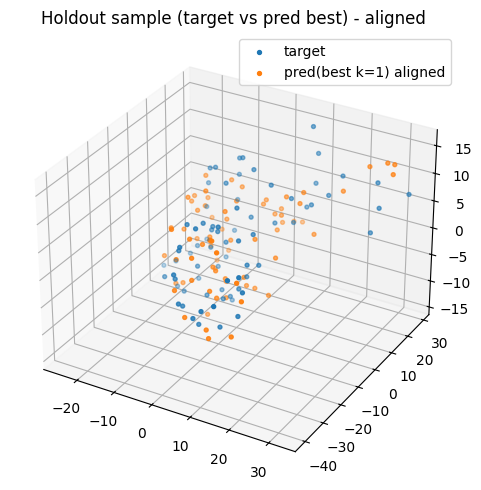

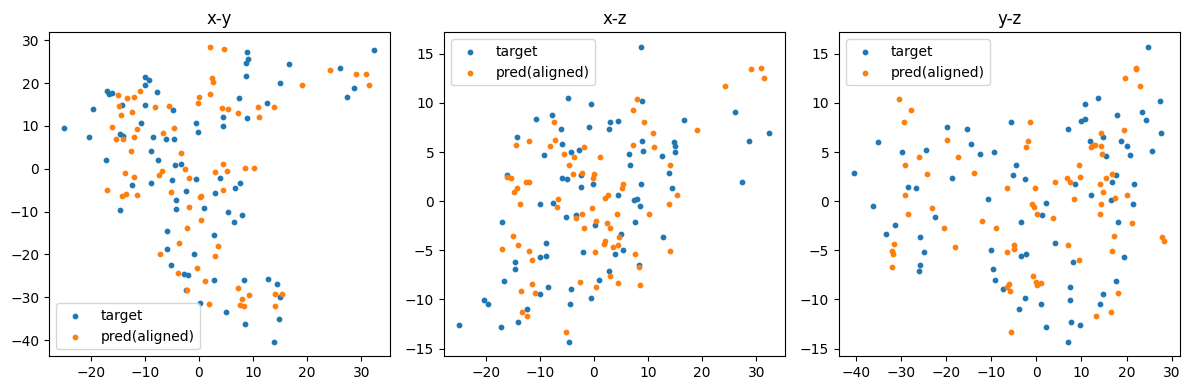

In [11]:
# ==========================================
# 7) Quick sanity check plots (3D + xy/xz/yz)  [v21]
#   - head0가 폭주/붕괴하는지 확인
#   - best head(holdout TM 기준) 시각화
# ==========================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

tokens, target, mask = next(iter(hold_loader))
tokens = tokens.to(device); target = target.to(device); mask = mask.to(device)
fb = filter_batch(tokens, target, mask, cfg.min_valid)
if fb is None:
    raise RuntimeError("hold batch has too few valid coords")
tokens, target, mask = fb
pad_mask = (tokens != 0)

model.eval()
with torch.inference_mode():
    preds, conf_logits = model(tokens, pad_mask)  # (B,K,T,3)

# metrics per head for sample 0
tm_per_head = []
rmsd_per_head = []
for k in range(cfg.num_preds):
    tm = tm_score_single(preds[0:1, k], target[0:1], mask[0:1])
    rm = kabsch_rmsd_losses(preds[0:1, k:k+1], target[0:1], mask[0:1]).squeeze(0).squeeze(0)
    tm_per_head.append(float(tm.item()))
    rmsd_per_head.append(float(rm.item()))

# --- best-k 선택: (1) TM 최대, (2) 혼합 기준(RMSD + alpha*dist) 최소 ---
best_k_tm = int(np.argmax(tm_per_head))
print("per-head TM:", [round(x,4) for x in tm_per_head], " best_k_tm=", best_k_tm)
print("per-head RMSD:", [round(x,4) for x in rmsd_per_head])

# sampled distance-matrix loss (국소 구조 보존 정도)
dist_bk = pairwise_distance_losses_sampled(preds, target, mask, num_pairs=int(getattr(cfg, "pair_num_pairs", 2048)))
dist_per_head = dist_bk[0].detach().cpu().numpy().tolist()
print("per-head Dist(sampled MSE):", [round(x,4) for x in dist_per_head])

alpha = float(getattr(cfg, "bestk_alpha", 0.30))
mix_score = [r + alpha*d for r, d in zip(rmsd_per_head, dist_per_head)]
best_k_mix = int(np.argmin(mix_score))
print("per-head MixScore(RMSD + alpha*Dist):", [round(x,4) for x in mix_score], f" alpha={alpha}  best_k_mix=", best_k_mix)

# 시각화는 mix 기준(best_k_mix)로 진행 (TM 기준도 비교 가능)
best_k = best_k_mix
# prepare coords
m0 = mask[0].bool()
tgt0 = target[0][m0]
pred_best = preds[0, best_k]
pred_0 = preds[0, 0]

# align both preds to target for fair viz
pred_best_a = kabsch_align(pred_best.unsqueeze(0), target[0].unsqueeze(0), mask[0:1]).squeeze(0)[m0]
pred0_a     = kabsch_align(pred_0.unsqueeze(0),   target[0].unsqueeze(0), mask[0:1]).squeeze(0)[m0]

# simple spread stats (radius of gyration proxy)
def rg(x):
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    return float(torch.sqrt((x*x).sum(dim=1).mean() + 1e-8).item())

print(f"Rg(target)={rg(tgt0):.3f}  Rg(pred_best_aligned)={rg(pred_best_a):.3f}  Rg(pred0_aligned)={rg(pred0_a):.3f}")

# --- 3D plot (best head aligned) ---
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tgt0[:,0].cpu(), tgt0[:,1].cpu(), tgt0[:,2].cpu(), s=8, label="target")
ax.scatter(pred_best_a[:,0].cpu(), pred_best_a[:,1].cpu(), pred_best_a[:,2].cpu(), s=8, label=f"pred(best k={best_k}) aligned")
ax.set_title("Holdout sample (target vs pred best) - aligned")
ax.legend()
plt.tight_layout()
plt.show()

# --- 2D projections ---
A = tgt0
B = pred_best_a

fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].scatter(A[:,0].cpu(), A[:,1].cpu(), s=10, label="target")
axes[0].scatter(B[:,0].cpu(), B[:,1].cpu(), s=10, label="pred(aligned)")
axes[0].set_title("x-y"); axes[0].legend()

axes[1].scatter(A[:,0].cpu(), A[:,2].cpu(), s=10, label="target")
axes[1].scatter(B[:,0].cpu(), B[:,2].cpu(), s=10, label="pred(aligned)")
axes[1].set_title("x-z"); axes[1].legend()

axes[2].scatter(A[:,1].cpu(), A[:,2].cpu(), s=10, label="target")
axes[2].scatter(B[:,1].cpu(), B[:,2].cpu(), s=10, label="pred(aligned)")
axes[2].set_title("y-z"); axes[2].legend()

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# Submission-style TM-score evaluation (competition rule)
#  - per target: best TM over (up to) 5 submitted predictions
#  - if multiple refs exist: best TM over refs
#  - final score: mean over targets of best TM
#
# Assumption consistent with rule text:
#  - residue equivalence is by residue index (same numbering) -> use mask positions only
#  - rotation/translation: superposition via Kabsch on those matched residues
# ============================================================
import math
import numpy as np
import pandas as pd
import torch

# ---- d0 exactly as described in your rule text ----
def tm_d0_competition(Lref: int) -> float:
    # Lref < 12, 12-15, 16-19, 20-23, 24-29 => 0.3,0.4,0.5,0.6,0.7
    if Lref < 12:   return 0.3
    if Lref <= 15:  return 0.4
    if Lref <= 19:  return 0.5
    if Lref <= 23:  return 0.6
    if Lref <= 29:  return 0.7
    # Lref >= 30: RNA용 d0 (노트북에서 이미 쓰고 있던 형태)
    return max(0.6 * math.sqrt(Lref - 0.5) - 2.5, 0.5)

def tm_score_superposition_competition(pred: torch.Tensor,
                                       ref: torch.Tensor,
                                       mask_ref: torch.Tensor) -> torch.Tensor:
    """
    pred/ref: (B,T,3)
    mask_ref: (B,T)  (ref에서 좌표가 해결된 잔기=1)
    returns: (B,) TM-score
    """
    pred_aligned = kabsch_align(pred, ref, mask_ref)  # 기존 함수 그대로 사용
    d = (pred_aligned.float() - ref.float()).norm(dim=-1)  # (B,T)
    m = mask_ref.bool()

    out = []
    for b in range(pred.shape[0]):
        idx = m[b]
        Lref = int(idx.sum().item())
        if Lref <= 0:
            out.append(pred.new_tensor(0.0, dtype=torch.float32))
            continue
        d0 = tm_d0_competition(Lref)
        db = d[b, idx]  # aligned residues distances
        # (1/Lref) * sum_i 1/(1 + (di/d0)^2)
        tm = (1.0 / (1.0 + (db / d0) ** 2)).sum() / Lref
        out.append(tm)

    return torch.stack(out, dim=0)

def _as_multi_ref(target, mask):
    """
    target/mask가 여러 ref를 담고 있을 수 있으니,
    항상 (B,R,T,3), (B,R,T) 형태로 맞춰서 반환.
    """
    if isinstance(target, (list, tuple)):
        # list of R tensors (B,T,3)
        targetR = torch.stack(target, dim=1)  # (B,R,T,3)
        if isinstance(mask, (list, tuple)):
            maskR = torch.stack(mask, dim=1)  # (B,R,T)
        else:
            maskR = mask.unsqueeze(1).expand(targetR.size(0), targetR.size(1), targetR.size(2))
        return targetR, maskR

    if target.dim() == 4:
        # target: (B,R,T,3)
        if mask.dim() == 2:
            maskR = mask.unsqueeze(1).expand(target.size(0), target.size(1), target.size(2))
        else:
            maskR = mask
        return target, maskR

    # single ref
    return target.unsqueeze(1), mask.unsqueeze(1)

def eval_submission_tm(loader,
                       ids_df=None,
                       k_submit=5,
                       pick_topk_by_conf=True,
                       max_batches=None):
    """
    loader: (tokens, target, mask) yielding DataLoader
    ids_df: (optional) dataset과 같은 순서의 DataFrame/list. target_id를 보여주고 싶을 때.
            - hold_loader면 hold_df[['target_id']].reset_index(drop=True) 권장
    k_submit: 제출 개수(규칙상 5)
    pick_topk_by_conf: K head가 5개 이상이면 conf_logits 상위 5개를 '제출'했다고 가정
    """
    model.eval()

    rows = []
    best_list = []

    global_base = 0  # batch 시작 시 dataset index base (shuffle=False 가정)

    with torch.no_grad():
        for bi, (tokens, target, mask) in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break

            B0 = tokens.size(0)

            tokens = tokens.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            mask   = mask.to(device, non_blocking=True)

            # --- keep: 최소 1개 residue라도 ref에 좌표가 있으면 평가 ---
            if mask.dim() == 2:
                keep = (mask.sum(dim=1) >= 1)
            else:
                # (B,R,T)라면 ref들 중 하나라도 1개 이상 있으면 keep
                keep = (mask.sum(dim=-1) >= 1).any(dim=1)

            if keep.sum() == 0:
                global_base += B0
                continue

            keep_idx = torch.nonzero(keep, as_tuple=False).squeeze(1).cpu().tolist()

            tokens_k = tokens[keep]
            target_k = target[keep]
            mask_k   = mask[keep]

            pad_mask = (tokens_k != 0)

            preds, conf_logits = model(tokens_k, pad_mask)  # preds: (b,K,T,3), conf: (b,K)
            b, K, T, _ = preds.shape

            # --- 어떤 5개를 제출했다고 볼지 결정 ---
            k_used = min(k_submit, K)
            if (K < k_submit):
                print(f"[info] 현재 모델 head(K)={K} < 제출요구({k_submit}) → best-of-{K}로 평가됩니다.")

            if pick_topk_by_conf and (conf_logits is not None) and conf_logits.numel() > 0:
                # sample별 conf 상위 k_used head를 제출했다고 가정
                submit_idx = torch.topk(conf_logits, k=k_used, dim=1).indices  # (b,k_used)
            else:
                # 그냥 앞에서부터 k_used개를 제출했다고 가정
                submit_idx = torch.arange(K, device=preds.device).unsqueeze(0).repeat(b, 1)[:, :k_used]

            # --- multi-ref 대응 ---
            targetR, maskR = _as_multi_ref(target_k, mask_k)  # (b,R,T,3), (b,R,T)
            R = targetR.size(1)

            # best tracking
            best_tm   = torch.full((b,), -1.0, device=preds.device)
            best_kidx = torch.zeros((b,), dtype=torch.long, device=preds.device)
            best_ridx = torch.zeros((b,), dtype=torch.long, device=preds.device)
            best_Lref = torch.zeros((b,), dtype=torch.long, device=preds.device)

            arange_b = torch.arange(b, device=preds.device)

            for r in range(R):
                ref_r  = targetR[:, r]      # (b,T,3)
                mref_r = maskR[:, r]        # (b,T)
                Lref_r = mref_r.bool().sum(dim=1).long()  # (b,)

                for j in range(k_used):
                    k_idx = submit_idx[:, j]  # (b,)
                    pred_j = preds[arange_b, k_idx]  # (b,T,3)

                    tm = tm_score_superposition_competition(pred_j, ref_r, mref_r)  # (b,)

                    better = tm > best_tm
                    best_tm   = torch.where(better, tm, best_tm)
                    best_kidx = torch.where(better, k_idx, best_kidx)
                    best_ridx = torch.where(better, torch.full_like(best_ridx, r), best_ridx)
                    best_Lref = torch.where(better, Lref_r, best_Lref)

            best_tm_cpu   = best_tm.detach().cpu().numpy()
            best_k_cpu    = best_kidx.detach().cpu().numpy()
            best_r_cpu    = best_ridx.detach().cpu().numpy()
            best_Lref_cpu = best_Lref.detach().cpu().numpy()

            # row 기록
            for ii in range(b):
                ds_idx = global_base + keep_idx[ii]
                target_id = None
                if ids_df is not None:
                    try:
                        if hasattr(ids_df, "iloc"):
                            # DataFrame
                            if "target_id" in ids_df.columns:
                                target_id = ids_df.iloc[ds_idx]["target_id"]
                            else:
                                target_id = ids_df.iloc[ds_idx].to_dict()
                        else:
                            # list
                            target_id = ids_df[ds_idx]
                    except Exception:
                        target_id = None

                rows.append({
                    "dataset_idx": int(ds_idx),
                    "target_id": target_id,
                    "Lref": int(best_Lref_cpu[ii]),
                    "best_TM": float(best_tm_cpu[ii]),
                    "best_pred_k": int(best_k_cpu[ii]),
                    "best_ref_r": int(best_r_cpu[ii]),
                    "K_total": int(K),
                    "K_used_as_submit": int(k_used),
                })

            best_list.extend(best_tm_cpu.tolist())
            global_base += B0

    res_df = pd.DataFrame(rows).sort_values("dataset_idx").reset_index(drop=True)

    # 최종 점수 = 타깃별 best_TM 평균
    final_score = float(np.mean(best_list)) if len(best_list) else float("nan")

    print("\n========================")
    print("Submission-style TM-score")
    print("========================")
    print(f"evaluated targets: {len(best_list)}")
    print(f"FINAL SCORE (mean of per-target best_TM) = {final_score:.6f}")

    if len(best_list):
        arr = np.asarray(best_list, dtype=np.float64)
        print(f"mean={arr.mean():.6f}  std={arr.std():.6f}  median={np.median(arr):.6f}")
        print(f"q10={np.quantile(arr,0.10):.6f}  q90={np.quantile(arr,0.90):.6f}")

    # 보기 좋게: 최하/최상 몇 개
    if len(res_df) > 0:
        print("\n--- worst 10 ---")
        display(res_df.sort_values("best_TM", ascending=True).head(10))
        print("\n--- best 10 ---")
        display(res_df.sort_values("best_TM", ascending=False).head(10))

    return res_df, final_score


# ===== 실행 예시 (holdout 기준) =====
# hold_loader는 shuffle=False라서 hold_df 순서와 매칭됩니다.
ids_df = None
if ("hold_df" in globals()) and ("target_id" in hold_df.columns):
    ids_df = hold_df[["target_id"]].reset_index(drop=True)

res_df, final_score = eval_submission_tm(
    hold_loader,
    ids_df=ids_df,
    k_submit=5,              # 규칙상 5
    pick_topk_by_conf=True,  # K>=5면 conf 상위 5개를 제출했다고 가정
    max_batches=None         # 빠르게 테스트면 5 같은 숫자로
)

[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 평가됩니다.
[info] 현재 모델 head(K)=4 < 제출요구(5) → best-of-4로 

,dataset_idx,target_id,Lref,best_TM,best_pred_k,best_ref_r,K_total,K_used_as_submit
385,385,2C4R,40,0.000818,3,0,4,4
402,402,1ZBH,32,0.001805,3,0,4,4
565,565,5U9B,15,0.002946,0,0,4,4
376,376,5LM7,29,0.003715,0,0,4,4
473,473,7Y7P,35,0.003847,2,0,4,4
354,354,9AUS,22,0.004523,0,0,4,4
32,32,9RVP,30,0.004962,0,0,4,4
54,54,9MTY,36,0.005825,2,0,4,4
342,342,8JHP,27,0.005849,1,0,4,4
396,396,4IFD,30,0.006402,0,0,4,4



--- best 10 ---


,dataset_idx,target_id,Lref,best_TM,best_pred_k,best_ref_r,K_total,K_used_as_submit
64,64,7AFI,256,0.461853,3,0,4,4
139,139,7OIF,256,0.459977,3,0,4,4
425,425,7OT5,256,0.459791,3,0,4,4
331,331,8Y5L,255,0.458957,3,0,4,4
490,490,6XDR,256,0.458802,3,0,4,4
96,96,3JA1,256,0.458792,3,0,4,4
237,237,7S1H,256,0.456693,3,0,4,4
247,247,8P17,250,0.456585,3,0,4,4
504,504,7BOI,256,0.456238,3,0,4,4
525,525,8QK7,250,0.455429,3,0,4,4


In [13]:
# ============================================================
# Make submission.csv from test_sequences.csv
# Output format:
# ID,resname,resid,x_1,y_1,z_1,...,x_5,y_5,z_5
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- 0) 필수 파일 체크 ----
test_path = _p("test_sequences.csv")
assert os.path.exists(test_path), f"test_sequences.csv 파일을 찾을 수 없습니다: {test_path}"

test_seq = pd.read_csv(test_path)
assert "target_id" in test_seq.columns and "sequence" in test_seq.columns, \
    "test_sequences.csv에는 target_id, sequence 컬럼이 있어야 합니다."

test_seq["target_id"] = test_seq["target_id"].astype(str).str.strip()
test_seq["sequence"]  = test_seq["sequence"].astype(str).str.strip()

# ---- 1) 토크나이즈 (노트북 앞에서 mapping/tokenize_sequence를 정의했다면 그걸 그대로 사용) ----
# 만약 tokenize_sequence가 없다면 아래를 사용:
if "tokenize_sequence" not in globals():
    mapping = {'A': 1, 'C': 2, 'G': 3, 'U': 4}
    def tokenize_sequence(seq: str):
        return [mapping.get(ch, 0) for ch in seq]

test_seq["tokens"] = test_seq["sequence"].apply(tokenize_sequence)
test_seq["L"] = test_seq["tokens"].apply(len)

# ---- 2) (안전장치) max_len 확장 필요하면 모델을 늘림 ----
def resize_model_max_len_inplace(model, new_max_len: int):
    """
    기존 학습된 weight는 유지하면서,
    - positional embedding 길이 확장
    - multiscale edge buffer 재생성
    """
    old_max_len = int(model.cfg.max_len)
    if new_max_len <= old_max_len:
        return

    print(f"[resize] model.cfg.max_len {old_max_len} -> {new_max_len}")

    # (1) positional embedding 확장
    old_pe = model.posenc.pe
    d_model = old_pe.embedding_dim
    new_pe = nn.Embedding(new_max_len, d_model).to(old_pe.weight.device)
    nn.init.normal_(new_pe.weight, mean=0.0, std=0.02)
    with torch.inference_mode():
        new_pe.weight[:old_pe.num_embeddings].copy_(old_pe.weight)
    model.posenc.pe = new_pe

    # (2) edge buffer 재생성 (CPU에서 만든 뒤 buffer에 덮어쓰기)
    ei, el = build_multiscale_edges(
        new_max_len, model.cfg.k_nn, model.cfg.long_dilations, device=torch.device("cpu")
    )
    model.edge_index_base = ei
    model.edge_long_base  = el

    # (3) cfg 업데이트
    model.cfg.max_len = int(new_max_len)

max_test_len = int(test_seq["L"].max())
if max_test_len > int(model.cfg.max_len):
    resize_model_max_len_inplace(model, max_test_len)

MAX_LEN = int(model.cfg.max_len)

# ---- 3) Test Dataset / Loader ----
class TestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, max_len: int):
        self.df = df.reset_index(drop=True)
        self.max_len = int(max_len)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        tokens = np.array(self.df.loc[idx, "tokens"], dtype=np.int64)
        L = int(len(tokens))
        # pad to max_len
        out = np.zeros((self.max_len,), dtype=np.int64)
        out[:min(L, self.max_len)] = tokens[:min(L, self.max_len)]
        return torch.from_numpy(out), L

test_ds = TestDataset(test_seq, MAX_LEN)
test_loader = DataLoader(
    test_ds,
    batch_size=getattr(cfg, "batch", 8),
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

# ---- 4) Inference + submission rows build ----
model.eval()

dfs = []
k_submit = 5

with torch.inference_mode():
    base_idx = 0
    for tokens_pad, Ls in test_loader:
        tokens_pad = tokens_pad.to(device, non_blocking=True)
        pad_mask = (tokens_pad != 0)

        preds, conf_logits = model(tokens_pad, pad_mask)  # preds: (B,K,T,3), conf: (B,K)
        B, K, T, _ = preds.shape

        # 샘플별 제출 5개 head 선택:
        # - K>=5: conf 상위 5개
        # - K<5: conf 상위 K개 + 1등 head 복제해서 5개 채움
        if conf_logits is None:
            order = torch.arange(K, device=preds.device).unsqueeze(0).repeat(B, 1)
        else:
            order = torch.argsort(conf_logits, dim=1, descending=True)  # (B,K)

        k_used = min(k_submit, K)
        topk = order[:, :k_used]  # (B,k_used)

        if K < k_submit:
            pad = topk[:, :1].repeat(1, k_submit - K)  # best head repeat
            topk5 = torch.cat([topk, pad], dim=1)      # (B,5)
        else:
            topk5 = topk[:, :k_submit]                 # (B,5)

        # preds5: (B,5,T,3)
        idx_b = torch.arange(B, device=preds.device).unsqueeze(1)  # (B,1)
        preds5 = preds[idx_b, topk5]                               # (B,5,T,3)

        preds5 = preds5.detach().cpu().numpy().astype(np.float32, copy=False)

        # batch 내 각 샘플 처리(잔기 loop 제거)
        cols = []
        for p in range(1, 6):
            cols += [f"x_{p}", f"y_{p}", f"z_{p}"]

        for i in range(B):
            ds_i = base_idx + i
            target_id = test_seq.loc[ds_i, "target_id"]
            seq = test_seq.loc[ds_i, "sequence"]
            L = int(Ls[i])

            # 혹시라도 L이 MAX_LEN을 넘으면(확장 안 된 상황) 잘라서라도 저장(최소한 에러 방지)
            L = min(L, T, len(seq))
            if L <= 0:
                continue

            coords = preds5[i, :, :L, :]  # (5,L,3)
            coords = coords.transpose(1, 0, 2).reshape(L, 15)  # (L,5*3)

            df_i = pd.DataFrame(coords, columns=cols)
            df_i.insert(0, "resid", np.arange(1, L + 1, dtype=np.int32))
            df_i.insert(0, "resname", list(seq[:L]))
            df_i.insert(0, "ID", [f"{target_id}_{r}" for r in range(1, L + 1)])

            dfs.append(df_i)

        base_idx += B

sub_df = pd.concat(dfs, ignore_index=True)

# (선택) 컬럼 순서 강제
cols = ["ID", "resname", "resid"]
for p in range(1, 6):
    cols += [f"x_{p}", f"y_{p}", f"z_{p}"]
sub_df = sub_df[cols]

sub_df.to_csv("submission.csv", index=False)
print("Saved: submission.csv")
print("submission shape:", sub_df.shape)
display(sub_df.head(10))

[resize] model.cfg.max_len 256 -> 4640
Saved: submission.csv
submission shape: (9762, 18)


,ID,resname,resid,x_1,y_1,z_1,x_2,y_2,z_2,x_3,y_3,z_3,x_4,y_4,z_4,x_5,y_5,z_5
0,8ZNQ_1,A,1,-127.447258,-32.232414,45.732014,-138.628387,-54.300842,-70.308731,-126.019440,-71.110962,-33.986420,-119.885674,-56.760536,65.668922,-127.447258,-32.232414,45.732014
1,8ZNQ_2,C,2,-122.010384,-34.369614,45.637688,-134.801285,-52.823071,-68.817009,-121.586555,-70.613602,-30.947739,-114.349518,-59.711361,66.230019,-122.010384,-34.369614,45.637688
2,8ZNQ_3,C,3,-120.347557,-37.197990,48.449482,-133.536331,-54.602146,-64.820450,-120.237610,-72.610512,-26.868704,-112.635460,-62.706608,68.983421,-120.347557,-37.197990,48.449482
3,8ZNQ_4,G,4,-121.872063,-41.739555,48.004513,-136.932236,-54.662605,-63.096756,-122.923088,-73.924942,-23.436913,-114.041306,-68.170143,69.186935,-121.872063,-41.739555,48.004513
4,8ZNQ_5,U,5,-125.390083,-46.488911,49.706573,-141.320923,-57.161186,-59.742069,-127.034813,-76.957802,-19.475323,-117.513474,-73.289864,71.066528,-125.390083,-46.488911,49.706573
5,8ZNQ_6,G,6,-127.645416,-50.559074,46.449089,-146.208801,-54.231079,-56.848404,-131.163635,-75.626862,-15.221706,-119.559967,-78.432999,68.029701,-127.645416,-50.559074,46.449089
6,8ZNQ_7,A,7,-128.952621,-54.120502,42.873184,-149.770248,-51.572910,-54.198280,-134.158127,-74.322746,-11.754804,-120.662758,-82.868759,64.376869,-128.952621,-54.120502,42.873184
7,8ZNQ_8,C,8,-131.820389,-52.569107,39.286922,-153.849243,-46.860909,-55.384106,-137.846619,-70.525658,-12.292019,-123.376625,-81.932915,60.841927,-131.820389,-52.569107,39.286922
8,8ZNQ_9,G,9,-131.426086,-51.702721,32.637276,-155.641678,-39.850586,-56.231812,-139.062637,-64.909370,-12.215223,-122.803230,-81.934990,54.161598,-131.426086,-51.702721,32.637276
9,8ZNQ_10,G,10,-130.795410,-50.816597,31.318680,-155.770264,-36.805832,-55.330284,-139.006760,-62.354404,-11.086803,-122.099251,-81.351097,52.760746,-130.795410,-50.816597,31.318680


In [14]:
# ============================================================
# v24: /kaggle/working 출력물 정리 (submission.csv만 남기기)
#  - Kaggle 제출에서는 submission.csv만 필요
#  - 다른 파일(체크포인트 등)은 /kaggle/temp로 이동
# ============================================================
import os, shutil, subprocess

WORK_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else os.getcwd()
TEMP_DIR = '/kaggle/temp' if os.path.exists('/kaggle/temp') else None
KEEP = {'submission.csv'}

def _ls_lh(path: str):
    try:
        out = subprocess.check_output(['bash','-lc', f'ls -lh {path}'], text=True)
        print(out)
    except Exception as e:
        print(f'[ls] failed on {path}:', e)

print('[ls] /kaggle/working (before)')
_ls_lh(WORK_DIR)

if TEMP_DIR is not None:
    move_dir = os.path.join(TEMP_DIR, 'moved_from_working_v24')
    os.makedirs(move_dir, exist_ok=True)
    for name in os.listdir(WORK_DIR):
        if name in KEEP:
            continue
        src = os.path.join(WORK_DIR, name)
        dst = os.path.join(move_dir, name)
        try:
            shutil.move(src, dst)
            print(f'[move] {name} -> {dst}')
        except Exception as e:
            print(f'[move] failed: {name} / {e}')
    print('\n[ls] /kaggle/working (after)')
    _ls_lh(WORK_DIR)
    print('\n[ls] moved_to_temp')
    _ls_lh(move_dir)
else:
    print('[cleanup] TEMP_DIR not found; skip moving files')


[ls] /kaggle/working (before)
[ls] failed on c:\Users\tkdwl\Desktop\Stanford RNA\stanford-rna-3d-folding-2: Command '['bash', '-lc', 'ls -lh c:\\Users\\tkdwl\\Desktop\\Stanford RNA\\stanford-rna-3d-folding-2']' returned non-zero exit status 2.
[cleanup] TEMP_DIR not found; skip moving files
